# Riesgo postcompra de vehículos en Panamá

## ACODECO 2024–2025 + ADAP 2024–2025

En este notebook fuimos dejando lo que ibamos encontrando poco a poco

Primero revisamos ACODECO para entender bien que datos teniamos
despues revisamos ADAP para ver las ventas por marca

Luego tratamos de unir las dos cosas y ahi fue donde nos dimos cuenta de algo importante

cuando unimos ACODECO con ADAP ya no podemos trabajar una reclamacion por fila
porque ADAP nos da las ventas por marca y por año

entonces nuestra unidad cambia a **marca + año**



## 0. Archivos que vamos a usar

para que esto corra igual cuando alguien descargue el repositorio dejamos los csv dentro de la carpeta `datos`

los nombres que vamos a usar son

- `decision-de-quejas-2024.csv`
- `decisionquejas_2025.csv`
- `ADAP_Ventas_Marcas_2025.csv`

la idea es que el notebook no dependa de mover archivos manualmente


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

carpeta_datos = Path("datos")

archivo_2024 = carpeta_datos / "decision-de-quejas-2024.csv"
archivo_2025 = carpeta_datos / "decisionquejas_2025.csv"
archivo_adap = carpeta_datos / "ADAP_Ventas_Marcas_2025.csv"

for archivo in [archivo_2024, archivo_2025, archivo_adap]:
    print(archivo, "->", archivo.exists())


datos/decision-de-quejas-2024.csv -> True
,datos/decisionquejas_2025.csv -> True
,datos/ADAP_Ventas_Marcas_2025.csv -> True


# PARTE A — CONOCER ACODECO

Aquí todavía no pensamos en ADAP ni en el modelo.

Primero queremos saber qué tenemos realmente en los archivos de reclamaciones.


## 1. Cargar 2024 y 2025 por separado


In [2]:
df_2024 = pd.read_csv(
    archivo_2024,
    sep=";",
    encoding="cp850"
)

df_2025 = pd.read_csv(
    archivo_2025,
    sep=";",
    encoding="latin1"
)

print("ACODECO 2024:", df_2024.shape)
print("ACODECO 2025:", df_2025.shape)


ACODECO 2024: (1915, 17)
,ACODECO 2025: (2063, 17)


### Lo que encontramos

- 2024 tiene **1,915 filas y 17 columnas**.
- 2025 tiene **2,063 filas y 17 columnas**.

Antes de unirlos revisamos que realmente tengan la misma estructura.


## 2. Revisar si hay filas completamente vacías


In [3]:
print("Filas totalmente vacías 2024:", df_2024.isna().all(axis=1).sum())
print("Filas totalmente vacías 2025:", df_2025.isna().all(axis=1).sum())


Filas totalmente vacías 2024: 0
,Filas totalmente vacías 2025: 0


No eliminamos filas solo porque tengan algún dato vacío.  
Solamente eliminaríamos una fila si está completamente vacía.


In [4]:
df_2024 = df_2024.dropna(how="all")
df_2025 = df_2025.dropna(how="all")


## 3. Comparar las columnas


In [5]:
print("Mismas columnas:", df_2024.columns.tolist() == df_2025.columns.tolist())

print("\nColumnas:")
for columna in df_2024.columns:
    print("-", columna)


Mismas columnas: True
,
,Columnas:
,- Departamento  de la Institución
,- Provincias dela República  de Panamá
,- Tipo de Ley
,- Fecha de Entrada de Queja
,- Mes de Entrada de Queja
,- Motivo de Queja
,- Agente Económico
,- Actividad
,- Marca de Producto
,- Producto
,- Velor de Apertura de Queja
,- Resultado de Queja
,- Efectivo Devuelto al Consumidor (B/.)
,- Fecha de Cierre de Queja
,- Mes Cierre de Queja
,- Año Cierre de Queja
,- Año Recibido de Queja


### Lo que encontramos

Los dos archivos tienen las mismas 17 columnas y en el mismo orden.

Eso nos permite unirlos sin tener que inventar equivalencias entre columnas.


## 4. Agregar el año y unir los archivos


In [6]:
df_2024["anio"] = 2024
df_2025["anio"] = 2025

acodeco = pd.concat(
    [df_2024, df_2025],
    ignore_index=True
)

print("ACODECO unido:", acodeco.shape)
display(acodeco.head())


ACODECO unido: (3978, 18)


,Departamento de la Institución,Provincias dela República de Panamá,Tipo de Ley,Fecha de Entrada de Queja,Mes de Entrada de Queja,Motivo de Queja,Agente Económico,Actividad,Marca de Producto,Producto,Velor de Apertura de Queja,Resultado de Queja,Efectivo Devuelto al Consumidor (B/.),Fecha de Cierre de Queja,Mes Cierre de Queja,Año Cierre de Queja,Año Recibido de Queja,anio
0,Decisión,Panamá,Ley 45 de 2007,45320,Ene 24,Incumplimiento de garantía,REDPRECIO.COM,Electrodomésticos/equipos electrónicos,HP,Computadora,213.99,Desistimiento/Devolución,213.99,45349.0,Feb 24,2024.0,2024,2024
1,Vehículo a Motor,Panamá,Ley 45 de 2007,45299,Ene 24,Incumplimiento de garantía,BAHIA MOTORS,Agencia de autos,Honda,Auto,775.0,Acuerdo en audiencia/Varios,NaN,45378.0,Mar 24,2024.0,2024,2024
2,Decisión,Panamá,Ley 45 de 2007,45295,Ene 24,Falta de información,"TINO RAMIREZ Y DANIEL, S.A.",Videojuegos,NaN,NaN,840.38,Desistimiento,NaN,45320.0,Ene 24,2024.0,2024,2024
3,Vehículo a Motor,Panamá,Ley 45 de 2007,45301,Ene 24,Incumplimiento de garantía,"GRUPO AUTO COMERCIAL, S.A.",Agencia de autos,GAP,Auto,18750.0,Desistimiento,NaN,45462.0,Jun 24,2024.0,2024,2024
4,Veracidad,Panamá,Ley 45 de 2007,45316,Ene 24,Veracidad de la publicidad,PRICESMART,Supermercados,NaN,NaN,559.99,En proceso,NaN,NaN,NaN,NaN,2024,2024


### Lo que encontramos

Después de unir los dos años tenemos **3,978 reclamaciones**.

Ahora aparecen 18 columnas porque nosotros agregamos `anio` para saber de qué archivo salió cada registro.


## 5. Revisar los departamentos de ACODECO


In [7]:
tabla_departamentos = pd.crosstab(
    acodeco["Departamento  de la Institución"],
    acodeco["anio"]
)

display(tabla_departamentos)


anio,2024,2025
Departamento de la Institución,,
Decisión,1518,1504
Vehículo a Motor,387,537
Veracidad,10,22


### Lo que encontramos

Nuestro proyecto es de vehículos, así que nos interesa el departamento **Vehículo a Motor**:

- 2024: 387 reclamaciones
- 2025: 537 reclamaciones
- Total: **924 reclamaciones**

Todavía no significa que las 924 se puedan comparar con las ventas de autos nuevos de ADAP.


## 6. Quedarnos con Vehículo a Motor


In [8]:
vehiculos = acodeco[
    acodeco["Departamento  de la Institución"] == "Vehículo a Motor"
].copy()

print("Registros de Vehículo a Motor:", vehiculos.shape)
display(vehiculos["anio"].value_counts().sort_index())


Registros de Vehículo a Motor: (924, 18)


anio
2024    387
2025    537
Name: count, dtype: int64

## 6.1 Ver las reclamaciones de Vehículo a Motor por año

Antes de seguir filtrando, hacemos una gráfica sencilla para ver cómo se reparten las reclamaciones entre los dos años.


anio
2024    387
2025    537
Name: count, dtype: int64

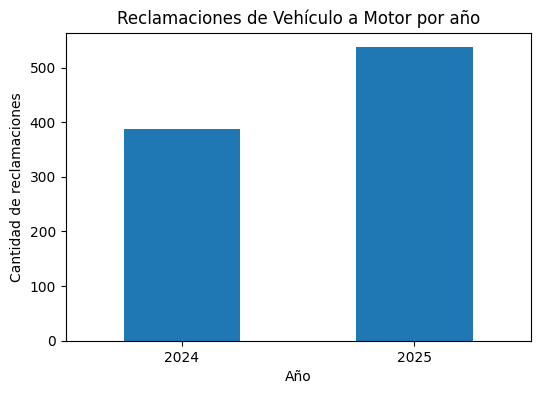

In [9]:
reclamos_por_anio = (
    vehiculos["anio"]
    .value_counts()
    .sort_index()
)

display(reclamos_por_anio)

reclamos_por_anio.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Reclamaciones de Vehículo a Motor por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de reclamaciones")
plt.xticks(rotation=0)
plt.show()


### Lo que vemos

En 2025 aparecen más reclamaciones que en 2024.

Esto solo describe lo que hay en ACODECO. Todavía no significa que el riesgo haya aumentado, porque también puede haber diferencias en ventas, cantidad de vehículos o forma de reportar.


## 7. Revisar las actividades dentro de Vehículo a Motor


In [10]:
display(
    vehiculos["Actividad"]
    .value_counts(dropna=False)
)


Actividad
Agencia de autos                                       332
Venta de autos usados                                  218
Taller de reparación de autos                          159
Repuestos para autos                                   115
Agencia de motos                                        25
Estaciones de gasolinas                                 17
Alquiler de autos                                       16
Servicios de grúas                                       7
Repuestos y reparaciones (talleres varios no autos)      7
Servicios de instalación                                 6
Lavautos                                                 4
Almacén por departamentos                                4
Servicio de intermediación                               3
Ferreterías, materiales de construccion o similares      3
Transporte (fletes, encomiendas y similares)             1
Almacén de ropa y calzados                               1
Envío de dinero                               

### Lo que encontramos

Aquí aparece una diferencia importante.

Dentro de `Vehículo a Motor` no hay solamente compras de autos nuevos. También hay:

- autos usados,
- talleres,
- repuestos,
- motos,
- alquileres,
- gasolineras,
- grúas,
- otros servicios.

Por eso **no podemos dividir las 924 reclamaciones directamente entre las ventas de autos nuevos de ADAP**.


## 8. Separar las actividades que sí son del negocio de autos

Primero hacemos un grupo amplio de actividades de autos. Esto nos sirve para entender mejor el sector antes de aplicar el filtro final.


In [11]:
actividades_autos = [
    "Agencia de autos",
    "Venta de autos usados",
    "Taller de reparación de autos",
    "Repuestos para autos",
    "Alquiler de autos"
]

sector_autos = vehiculos[
    vehiculos["Actividad"].isin(actividades_autos)
].copy()

print("Registros en estas actividades:", len(sector_autos))
display(
    pd.crosstab(
        sector_autos["Actividad"],
        sector_autos["anio"]
    )
)


Registros en estas actividades: 840


anio,2024,2025
Actividad,,
Agencia de autos,149,183
Alquiler de autos,14,2
Repuestos para autos,45,70
Taller de reparación de autos,64,95
Venta de autos usados,81,137


### Lo que encontramos

Después de exigir primero que el registro pertenezca a `Vehículo a Motor`, estas cinco actividades suman **840 reclamaciones**.

Este número es importante porque en una versión anterior aparecían 857. Ese valor incluía 17 registros de otros departamentos que tenían nombres de actividad similares.

Para mantener la trazabilidad, usamos **840** como el grupo amplio de actividades de autos dentro de `Vehículo a Motor`.


## 9. Revisar los productos por año


In [12]:
tabla_productos = pd.crosstab(
    sector_autos["Producto"],
    sector_autos["anio"]
)

display(
    tabla_productos
    .assign(Total=tabla_productos.sum(axis=1))
    .sort_values("Total", ascending=False)
    .head(25)
)


anio,2024,2025,Total
Producto,,,
Automóvil,0,449,449
Auto,316,0,316
Pieza de Repuesto,11,13,24
Batería de auto,4,5,9
No se Registro,0,8,8
Moto,3,4,7
Llanta,2,1,3
Amortiguadores,0,2,2
Transmisión,0,2,2


### Lo que encontramos

El mismo producto aparece escrito diferente según el año:

- en 2024 aparece principalmente `Auto`;
- en 2025 aparece `Automóvil`.

Para poder comparar los años vamos a crear una columna nueva y dejar ambos como `AUTOMOVIL`.


## 10. Crear una versión estándar del producto


In [13]:
sector_autos["producto_std"] = (
    sector_autos["Producto"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({
        "AUTO": "AUTOMOVIL",
        "AUTOMÓVIL": "AUTOMOVIL"
    })
)

display(sector_autos["producto_std"].value_counts(dropna=False).head(20))


producto_std
AUTOMOVIL            765
PIEZA DE REPUESTO     24
<NA>                  16
BATERÍA DE AUTO        9
NO SE REGISTRO         8
MOTO                   7
LLANTA                 3
MOTOR DE AUTO          2
AMORTIGUADORES         2
TRANSMISIÓN            2
#¡NULO!                1
COMPRESOR DE AIRE      1
Name: count, dtype: Int64

## 11. Revisar valores faltantes


In [14]:
nulos = pd.DataFrame({
    "Cantidad": sector_autos.isna().sum(),
    "Porcentaje": (sector_autos.isna().mean() * 100).round(2)
})

display(nulos.sort_values("Porcentaje", ascending=False))


,Cantidad,Porcentaje
Efectivo Devuelto al Consumidor (B/.),832,99.05
Año Cierre de Queja,724,86.19
Fecha de Cierre de Queja,724,86.19
Mes Cierre de Queja,724,86.19
Marca de Producto,54,6.43
producto_std,16,1.90
Producto,16,1.90
Tipo de Ley,0,0.00
Provincias dela República de Panamá,0,0.00
Departamento de la Institución,0,0.00


### Lo que encontramos

Las columnas de cierre y efectivo devuelto tienen muchos faltantes.

Eso no significa necesariamente que el dato esté mal: muchas reclamaciones todavía pueden estar en proceso.

Por ahora no vamos a usar esas columnas para decidir qué registros entran en la unión con ADAP.


## 12. Revisar motivos de queja


In [15]:
display(
    sector_autos["Motivo de Queja"]
    .value_counts(dropna=False)
)


Motivo de Queja
Incumplimiento de garantía    528
Falta de información          106
Incumplimiento de servicio    102
Custodia de bien               44
Devolución de dinero           19
Incumplimiento de contrato     14
Vicio oculto                   12
Daños y perjuicios              5
Cobro indebido                  4
Venta engañosa                  4
Veracidad de la publicidad      1
Mercancía defectuosa            1
Name: count, dtype: int64

### Lo que encontramos

`Incumplimiento de garantía` es el motivo que más aparece.

Más adelante vamos a resumir los motivos por marca y año para usarlos como características del perfil de reclamaciones.


## 13. Revisar marcas


In [16]:
display(
    sector_autos["Marca de Producto"]
    .value_counts(dropna=False)
    .head(40)
)


Marca de Producto
Hyundai           100
Toyota             96
KIA                93
Nissan             75
No se Registro     57
NaN                54
Chevrolet          51
Suzuki             34
Honda              28
Ford               22
Changan            20
Mitsubishi         19
GAC                16
Jetour             15
Mazda              12
Cherry             11
MG                 10
Geely               9
BMW                 8
Kaiyi               8
Audi                7
JEEP                7
Dongfeng            5
Forthing            5
Volkswagen          5
Land Rover          5
Mercedez Benz       5
Peugeot             4
Isuzu               4
Maxus               4
Renault             4
Volvo               4
Karry               3
Fiat                3
Porsche             2
Lexus               2
Subaru              2
Omoda               2
VGV                 2
Chery QQ            2
Name: count, dtype: int64

### Lo que encontramos

Hay marcas bien identificadas, pero también:

- valores vacíos,
- `No se Registro`,
- nombres escritos de forma diferente.

No vamos a borrar la marca original. Crearemos otra columna solamente para hacer el match con ADAP.


## 13.1 Ver las marcas con más reclamaciones

Esta gráfica nos gustaba porque ayuda a ver rápidamente qué marcas aparecen más veces en ACODECO.

Por ahora es solo un conteo. Después veremos cómo cambia la lectura cuando agregamos las ventas de ADAP.


Marca de Producto
Hyundai       100
Toyota         96
KIA            93
Nissan         75
Chevrolet      51
Suzuki         34
Honda          28
Ford           22
Changan        20
Mitsubishi     19
GAC            16
Jetour         15
Mazda          12
Cherry         11
MG             10
Name: count, dtype: int64

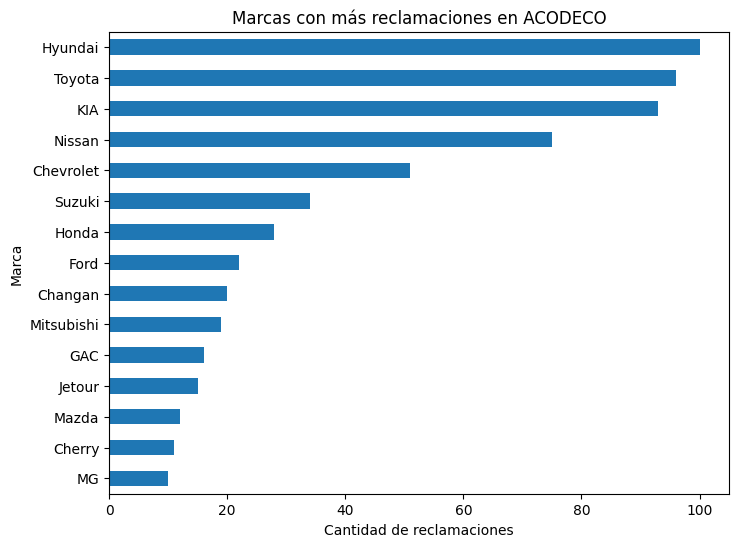

In [17]:
top_marcas_acodeco = (
    sector_autos["Marca de Producto"]
    .dropna()
    .loc[lambda s: s != "No se Registro"]
    .value_counts()
    .head(15)
)

display(top_marcas_acodeco)

top_marcas_acodeco.sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("Marcas con más reclamaciones en ACODECO")
plt.xlabel("Cantidad de reclamaciones")
plt.ylabel("Marca")
plt.show()


### Lo que vemos

Hay marcas que aparecen mucho más que otras en cantidad de reclamaciones.

Pero todavía no podemos decir que tengan mayor riesgo. Una marca que vende muchos más vehículos también puede acumular más reclamaciones simplemente por tener mayor presencia en el mercado.

Esta es una de las razones por las que necesitamos ADAP.


## 14. Revisar productos, resultados y provincias


In [18]:
print("PRODUCTOS")
display(sector_autos["Producto"].value_counts(dropna=False).head(20))

print("\nRESULTADOS")
display(sector_autos["Resultado de Queja"].value_counts(dropna=False))

print("\nPROVINCIAS")
display(
    sector_autos["Provincias dela República  de Panamá"]
    .value_counts(dropna=False)
)


PRODUCTOS


Producto
Automóvil            449
Auto                 316
Pieza de Repuesto     24
NaN                   16
Batería de auto        9
No se Registro         8
Moto                   7
Llanta                 3
Motor de Auto          2
Amortiguadores         2
Transmisión            2
#¡NULO!                1
Compresor de aire      1
Name: count, dtype: int64


,RESULTADOS


Resultado de Queja
En proceso                                   724
Desistimiento                                 73
Pendiente constancia desistimiento            14
Acuerdo en audiencia/Devolución de dinero     10
Acuerdo en audiencia/Varios                    7
Inhibe                                         4
Desistimiento/Devolución                       2
Transacción extrajudicial                      2
Abandono                                       1
Ministerio Público                             1
Acuerdo en audiencia/Reparación                1
Inadmitida                                     1
Name: count, dtype: int64


,PROVINCIAS


Provincias dela República  de Panamá
Panamá        695
Pmá Oeste      48
Chiriquí       45
Herrera        21
Veraguas       11
Coclé           8
Los Santos      7
Colón           4
Darién          1
Name: count, dtype: int64

### Lo que encontramos

La mayoría de los resultados todavía aparece como `En proceso`, así que por ahora no vamos a usar el resultado final de la queja como parte central del análisis.

También vemos que la mayoría de las reclamaciones se concentra en Panamá, pero eso por sí solo no significa mayor riesgo.


## 15. Convertir el monto de la queja a número


In [19]:
sector_autos["monto_queja"] = pd.to_numeric(
    sector_autos["Velor de Apertura de Queja"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

print("Montos válidos:", sector_autos["monto_queja"].notna().sum())
print("Montos no convertidos:", sector_autos["monto_queja"].isna().sum())

display(sector_autos["monto_queja"].describe().round(2))


Montos válidos: 840
,Montos no convertidos: 0


count      840.00
mean      9459.17
std       9581.73
min          0.00
25%        775.62
50%       5500.00
75%      18495.00
max      30000.00
Name: monto_queja, dtype: float64

# PARTE B — DE ACODECO GENERAL A RECLAMACIONES COMPARABLES CON ADAP

ADAP habla de **vehículos nuevos vendidos por marca**.

Por eso necesitamos una regla clara para no mezclar esas ventas con reclamaciones de talleres, repuestos o autos usados.


## 16. Aplicar el criterio de comparabilidad

Para esta primera integración usamos solamente:

- `Actividad == Agencia de autos`
- `producto_std == AUTOMOVIL`

Este filtro es una decisión del proyecto para acercar ACODECO al concepto de vehículo nuevo vendido por agencia.


In [20]:
reclamos_comparables = sector_autos[
    (sector_autos["Actividad"] == "Agencia de autos")
    & (sector_autos["producto_std"] == "AUTOMOVIL")
].copy()

print("Reclamaciones comparables:", len(reclamos_comparables))
display(
    reclamos_comparables["anio"]
    .value_counts()
    .sort_index()
)


Reclamaciones comparables: 321


anio
2024    144
2025    177
Name: count, dtype: int64

### Lo que encontramos

Quedan **321 reclamaciones comparables**:

- 2024: 144
- 2025: 177

Este es el subconjunto que vamos a intentar relacionar con las ventas de ADAP.


## 17. Preparar las marcas de ACODECO


In [21]:
reclamos_comparables["marca_original"] = (
    reclamos_comparables["Marca de Producto"]
)

reclamos_comparables["marca_std"] = (
    reclamos_comparables["Marca de Producto"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

reclamos_comparables["marca_std"] = reclamos_comparables["marca_std"].replace({
    "NO SE REGISTRO": pd.NA,
    "NO REGISTRADO": pd.NA,
    "#NULO!": pd.NA,
    "CHERRY": "CHERY",
    "CHERY QQ": "CHERY",
    "GAC": "GAC MOTOR",
    "DONGFENG": "DONG FENG",
    "MERCEDEZ BENZ": "MERCEDES BENZ",
    "MINI COOPER": "MINI",
    "IZUZU": "ISUZU"
})

print("Con marca identificada:", reclamos_comparables["marca_std"].notna().sum())

display(
    reclamos_comparables[
        ["marca_original", "marca_std"]
    ]
    .drop_duplicates()
    .sort_values("marca_std")
)


Con marca identificada: 298


,marca_original,marca_std
691,Ava,AVA
2410,Bestune,BESTUNE
1528,BMW,BMW
369,Changan,CHANGAN
3678,Chery QQ,CHERY
543,Cherry,CHERY
117,Chevrolet,CHEVROLET
3804,DFSK,DFSK
530,Dongfeng,DONG FENG
2922,Fiat,FIAT


### Lo que encontramos

De las 321 reclamaciones comparables, **298 tienen una marca identificable**.

Conservamos `marca_original` para poder rastrear cualquier corrección.


# PARTE C — CONOCER ADAP

Ahora dejamos ACODECO a un lado por un momento y revisamos ADAP como una fuente independiente.


## 18. Cargar ADAP


In [22]:
adap_original = pd.read_csv(
    archivo_adap,
    encoding="utf-8-sig"
)

print("ADAP:", adap_original.shape)
display(adap_original.head())


ADAP: (41, 6)


,ranking,marca,total_2025,total_2024,variacion_pct,participacion_pct
0,1.0,TOYOTA,11507,11189.0,2.8,19.1
1,2.0,KIA,7626,7457.0,2.3,12.7
2,3.0,HYUNDAI,6985,7048.0,-0.9,11.6
3,4.0,GEELY,3138,2345.0,33.8,5.2
4,5.0,SUZUKI,3094,2657.0,16.4,5.1


### Lo que encontramos

El archivo tiene **41 filas y 6 columnas**.

No son 41 marcas individuales: hay **40 marcas listadas individualmente + una fila `OTRAS MARCAS`**.


## 19. Revisar columnas, tipos y faltantes


In [23]:
print(adap_original.dtypes)

display(
    pd.DataFrame({
        "Cantidad": adap_original.isna().sum(),
        "Porcentaje": (adap_original.isna().mean() * 100).round(2)
    })
)


ranking              float64
,marca                 object
,total_2025             int64
,total_2024           float64
,variacion_pct        float64
,participacion_pct    float64
,dtype: object


,Cantidad,Porcentaje
ranking,1,2.44
marca,0,0.00
total_2025,0,0.00
total_2024,1,2.44
variacion_pct,1,2.44
participacion_pct,0,0.00


## 20. Validar los totales de ventas


In [24]:
total_2024 = adap_original["total_2024"].sum(skipna=True)
total_2025 = adap_original["total_2025"].sum(skipna=True)

print("Ventas 2024:", int(total_2024))
print("Ventas 2025:", int(total_2025))
print(
    "Crecimiento:",
    round((total_2025 - total_2024) / total_2024 * 100, 2),
    "%"
)


Ventas 2024: 54384
,Ventas 2025: 60233
,Crecimiento: 10.76 %


### Lo que encontramos

- 2024: **54,384 vehículos**
- 2025: **60,233 vehículos**
- Crecimiento aproximado: **10.76%**

Esto confirma que el tamaño del mercado cambia entre años.


## 21. Revisar las marcas con más ventas


In [25]:
print("2024")
display(
    adap_original[
        ["marca", "total_2024"]
    ]
    .sort_values("total_2024", ascending=False)
    .head(12)
)

print("\n2025")
display(
    adap_original[
        ["marca", "total_2025"]
    ]
    .sort_values("total_2025", ascending=False)
    .head(12)
)


2024


,marca,total_2024
0,TOYOTA,11189.0
1,KIA,7457.0
2,HYUNDAI,7048.0
4,SUZUKI,2657.0
6,NISSAN,2417.0
3,GEELY,2345.0
5,MITSUBISHI,2233.0
8,CHANGAN,1736.0
9,ISUZU,1584.0
40,OTRAS MARCAS,1552.0



,2025


,marca,total_2025
0,TOYOTA,11507
1,KIA,7626
2,HYUNDAI,6985
3,GEELY,3138
4,SUZUKI,3094
5,MITSUBISHI,2185
6,NISSAN,2166
7,JETOUR,1999
8,CHANGAN,1854
9,ISUZU,1747


### Lo que encontramos

Toyota, KIA y Hyundai aparecen entre las marcas con más ventas.

Esto refuerza la idea del proyecto: **un número alto de reclamaciones no se puede interpretar igual para una marca que vende 10,000 vehículos que para otra que vende 300**.


## 21.1 Comparar visualmente las ventas 2024 y 2025

Tomamos las principales marcas por ventas de 2025 y las comparamos con 2024.


,marca,total_2024,total_2025
0,TOYOTA,11189.0,11507
1,KIA,7457.0,7626
2,HYUNDAI,7048.0,6985
3,GEELY,2345.0,3138
4,SUZUKI,2657.0,3094
5,MITSUBISHI,2233.0,2185
6,NISSAN,2417.0,2166
7,JETOUR,1264.0,1999
8,CHANGAN,1736.0,1854
9,ISUZU,1584.0,1747


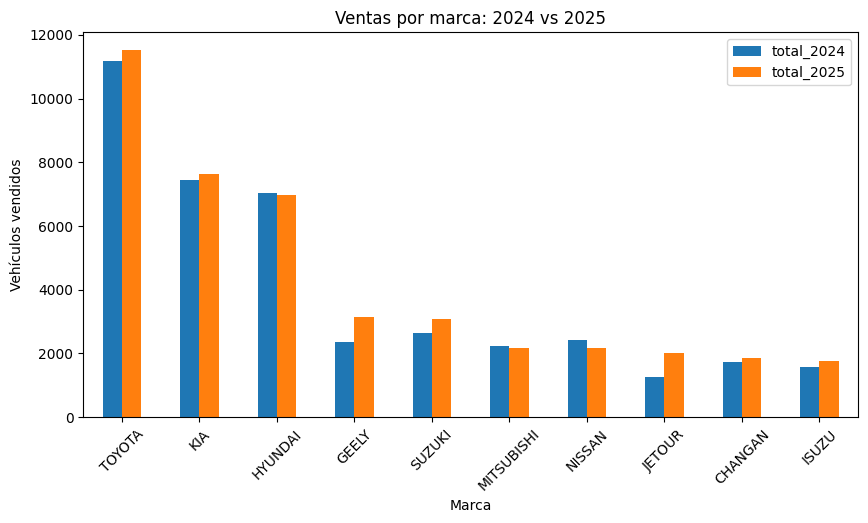

In [26]:
top10_adap = (
    adap_original[
        adap_original["marca"] != "OTRAS MARCAS"
    ]
    .sort_values("total_2025", ascending=False)
    .head(10)
)

display(
    top10_adap[
        ["marca", "total_2024", "total_2025"]
    ]
)

top10_adap[
    ["marca", "total_2024", "total_2025"]
].set_index("marca").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Ventas por marca: 2024 vs 2025")
plt.xlabel("Marca")
plt.ylabel("Vehículos vendidos")
plt.xticks(rotation=45)
plt.show()


### Lo que vemos

Las diferencias de volumen entre marcas son grandes.

Esto confirma que mirar solamente el número de reclamaciones puede ser engañoso. Necesitamos poner ese conteo en relación con las ventas.


## 22. Pasar ADAP al formato año + marca + ventas


In [27]:
adap = (
    adap_original[
        ["marca", "total_2024", "total_2025"]
    ]
    .melt(
        id_vars="marca",
        value_vars=["total_2024", "total_2025"],
        var_name="anio",
        value_name="ventas"
    )
)

adap["anio"] = (
    adap["anio"]
    .str.replace("total_", "", regex=False)
    .astype(int)
)

adap["marca_std"] = (
    adap["marca"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

display(adap.head(10))


,marca,anio,ventas,marca_std
0,TOYOTA,2024,11189.0,TOYOTA
1,KIA,2024,7457.0,KIA
2,HYUNDAI,2024,7048.0,HYUNDAI
3,GEELY,2024,2345.0,GEELY
4,SUZUKI,2024,2657.0,SUZUKI
5,MITSUBISHI,2024,2233.0,MITSUBISHI
6,NISSAN,2024,2417.0,NISSAN
7,JETOUR,2024,1264.0,JETOUR
8,CHANGAN,2024,1736.0,CHANGAN
9,ISUZU,2024,1584.0,ISUZU


# PARTE D — COMPROBAR SI LAS MARCAS COINCIDEN

Antes de hacer un `merge`, comprobamos qué tanto coincide ACODECO con ADAP.


## 23. Revisar el match de marcas


In [28]:
marcas_adap = set(
    adap.loc[
        adap["marca_std"] != "OTRAS MARCAS",
        "marca_std"
    ].dropna()
)

reclamos_comparables["coincide_adap"] = (
    reclamos_comparables["marca_std"].isin(marcas_adap)
)

total_comparable = len(reclamos_comparables)
identificables = reclamos_comparables["marca_std"].notna().sum()
con_match = reclamos_comparables["coincide_adap"].sum()

print("Reclamaciones comparables:", total_comparable)
print("Con marca identificable:", identificables)
print("Con match en ADAP:", con_match)
print("Cobertura sobre el total:", round(con_match / total_comparable * 100, 2), "%")
print("Cobertura entre las identificables:", round(con_match / identificables * 100, 2), "%")


Reclamaciones comparables: 321
,Con marca identificable: 298
,Con match en ADAP: 274
,Cobertura sobre el total: 85.36 %
,Cobertura entre las identificables: 91.95 %


### Lo que encontramos

- 321 reclamaciones comparables
- 298 con marca identificable
- 274 con match individual en ADAP
- cobertura total: **85.36%**
- cobertura entre las que sí tienen marca: aproximadamente **91.95%**

La unión sí es viable, aunque no cubre todos los registros.


## 24. Ver qué no logró coincidir


In [29]:
sin_match = (
    reclamos_comparables.loc[
        ~reclamos_comparables["coincide_adap"],
        "marca_std"
    ]
    .value_counts(dropna=False)
)

display(sin_match)


marca_std
<NA>       23
JEEP        5
PEUGEOT     3
KARRY       3
FIAT        2
VGV         2
YEMA        1
AVA         1
MINI        1
GAP         1
POER        1
BESTUNE     1
RAM         1
HAVAL       1
DFSK        1
Name: count, dtype: Int64

### Decisión

No vamos a forzar esas marcas dentro de `OTRAS MARCAS`.

Si ADAP no nos da una venta individual para una marca, no inventamos el denominador.


# PARTE E — PONER ACODECO Y ADAP EN LA MISMA UNIDAD

ADAP tiene una fila por **marca y año**.

Entonces ACODECO también debe resumirse a **marca y año** antes de hacer la unión.


## 25. Crear variables útiles de ACODECO por marca-año


In [30]:
reclamos_match = reclamos_comparables[
    reclamos_comparables["coincide_adap"]
].copy()

reclamos_match["monto_queja"] = pd.to_numeric(
    reclamos_match["Velor de Apertura de Queja"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

reclamos_match["es_garantia"] = (
    reclamos_match["Motivo de Queja"] == "Incumplimiento de garantía"
).astype(int)

reclamos_match["es_servicio"] = (
    reclamos_match["Motivo de Queja"] == "Incumplimiento de servicio"
).astype(int)

reclamos_match["es_falta_info"] = (
    reclamos_match["Motivo de Queja"] == "Falta de información"
).astype(int)

resumen_acodeco = (
    reclamos_match
    .groupby(["anio", "marca_std"])
    .agg(
        cantidad_quejas=("marca_std", "size"),
        monto_promedio=("monto_queja", "mean"),
        monto_mediano=("monto_queja", "median"),
        pct_garantia=("es_garantia", "mean"),
        pct_servicio=("es_servicio", "mean"),
        pct_falta_info=("es_falta_info", "mean"),
        motivos_distintos=("Motivo de Queja", "nunique")
    )
    .reset_index()
)

for columna in ["pct_garantia", "pct_servicio", "pct_falta_info"]:
    resumen_acodeco[columna] = resumen_acodeco[columna] * 100

display(resumen_acodeco.head(15).round(2))


,anio,marca_std,cantidad_quejas,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos
0,2024,BMW,1,851.34,851.34,100.00,0.00,0.0,1
1,2024,CHANGAN,6,20288.17,20488.50,100.00,0.00,0.0,1
2,2024,CHERY,3,19730.00,17300.00,100.00,0.00,0.0,1
3,2024,CHEVROLET,22,18044.28,18527.50,81.82,13.64,0.0,3
4,2024,DONG FENG,2,22500.00,22500.00,100.00,0.00,0.0,1
5,2024,FORD,2,269.69,269.69,50.00,50.00,0.0,2
6,2024,FORTHING,5,23366.02,23240.00,100.00,0.00,0.0,1
7,2024,GAC MOTOR,6,19050.00,18175.00,100.00,0.00,0.0,1
8,2024,GEELY,3,16932.63,24500.00,100.00,0.00,0.0,1
9,2024,HONDA,3,4216.75,775.00,100.00,0.00,0.0,1


### Qué significa esta tabla

Cada fila ya representa una combinación `marca-año`.

Además de contar reclamaciones, resumimos algunas características que después pueden servir para entender el perfil de esas reclamaciones:

- monto promedio,
- monto mediano,
- porcentaje por garantía,
- porcentaje por incumplimiento de servicio,
- porcentaje por falta de información,
- cantidad de motivos distintos.


## 26. Preparar ADAP a la misma unidad


In [31]:
adap_anual = (
    adap[
        (adap["marca_std"] != "OTRAS MARCAS")
        & adap["ventas"].notna()
    ][["anio", "marca_std", "ventas"]]
    .copy()
)

display(adap_anual.head(15))


,anio,marca_std,ventas
0,2024,TOYOTA,11189.0
1,2024,KIA,7457.0
2,2024,HYUNDAI,7048.0
3,2024,GEELY,2345.0
4,2024,SUZUKI,2657.0
5,2024,MITSUBISHI,2233.0
6,2024,NISSAN,2417.0
7,2024,JETOUR,1264.0
8,2024,CHANGAN,1736.0
9,2024,ISUZU,1584.0


# PARTE F — HACER LA UNIÓN

Ahora sí ambas tablas están en `marca + año`.


## 27. Unir ACODECO con ADAP


In [32]:
dataset_integrado = resumen_acodeco.merge(
    adap_anual,
    on=["anio", "marca_std"],
    how="inner"
)

print("Combinaciones marca-año:", len(dataset_integrado))
display(
    dataset_integrado
    .sort_values(["anio", "cantidad_quejas"], ascending=[True, False])
    .head(30)
    .round(2)
)


Combinaciones marca-año: 44


,anio,marca_std,cantidad_quejas,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos,ventas
3,2024,CHEVROLET,22,18044.28,18527.50,81.82,13.64,0.00,3,426.0
13,2024,KIA,18,14534.87,15022.50,94.44,0.00,0.00,2,7457.0
19,2024,TOYOTA,15,19147.66,20500.00,73.33,6.67,13.33,4,11189.0
10,2024,HYUNDAI,10,13472.66,15099.00,80.00,20.00,0.00,2,7048.0
17,2024,NISSAN,7,23239.81,28000.00,71.43,14.29,0.00,3,2417.0
18,2024,SUZUKI,7,12771.32,14740.00,85.71,14.29,0.00,2,2657.0
1,2024,CHANGAN,6,20288.17,20488.50,100.00,0.00,0.00,1,1736.0
7,2024,GAC MOTOR,6,19050.00,18175.00,100.00,0.00,0.00,1,1129.0
6,2024,FORTHING,5,23366.02,23240.00,100.00,0.00,0.00,1,727.0
16,2024,MITSUBISHI,4,7111.04,1186.53,50.00,0.00,25.00,3,2233.0


### Lo que encontramos

Después de poner ACODECO y ADAP al mismo nivel, obtenemos **44 combinaciones marca-año**.

A partir de este punto, estas 44 filas pasan a ser nuestro **conjunto de trabajo para el modelo**.

Cada fila representa una combinación real de una marca en un año determinado.

Por ejemplo:

- TOYOTA - 2024
- TOYOTA - 2025
- KIA - 2024
- KIA - 2025

Ya no estamos trabajando con reclamaciones individuales, sino con el resumen de cada marca-año junto con sus ventas y las características de sus reclamaciones.


## 27.1 Por que nuestro conjunto para el modelo tiene 44 filas

Este punto nos costo entenderlo al principio asi que lo dejamos explicado

empezamos con reclamaciones individuales de ACODECO

pero ADAP no tiene una fila por reclamacion
ADAP tiene las ventas por **marca y año**

entonces para unir las dos fuentes tenemos que poner ACODECO al mismo nivel

por ejemplo si tenemos varias reclamaciones de Toyota en 2025
las resumimos en una sola fila Toyota 2025

ahi guardamos cuantas reclamaciones tuvo esa marca ese año
el monto promedio
los motivos que aparecen
y luego le agregamos las ventas de ADAP

al hacer eso nos quedan

- 21 combinaciones marca-año en 2024
- 23 combinaciones marca-año en 2025
- **44 combinaciones en total**
- 27 marcas diferentes
- 17 marcas aparecen en los dos años
- 10 aparecen solo en uno

estas **44 observaciones son las que usamos para el modelo**

preferimos quedarnos con esas 44 filas reales
antes que repetir el mismo dato de ventas muchas veces solo para que parezca que tenemos mas registros


In [33]:
print("Filas marca-año:", len(dataset_integrado))
print("Marcas diferentes:", dataset_integrado["marca_std"].nunique())

apariciones_por_marca = (
    dataset_integrado
    .groupby("marca_std")["anio"]
    .nunique()
)

print(
    "Marcas presentes en ambos años:",
    (apariciones_por_marca == 2).sum()
)

print(
    "Marcas presentes en un solo año:",
    (apariciones_por_marca == 1).sum()
)

display(
    dataset_integrado
    .groupby("anio")
    .size()
    .rename("combinaciones_marca_anio")
)


Filas marca-año: 44
,Marcas diferentes: 27
,Marcas presentes en ambos años: 17
,Marcas presentes en un solo año: 10


anio
2024    21
2025    23
Name: combinaciones_marca_anio, dtype: int64

## 27.2 Como pasamos de 274 reclamaciones a las 44 observaciones del modelo

Las 274 filas todavia son reclamaciones individuales

por ejemplo podemos tener

- Toyota 2025 reclamacion 1
- Toyota 2025 reclamacion 2
- Toyota 2025 reclamacion 3

pero para Toyota 2025 ADAP tiene un solo valor de ventas

entonces todas esas reclamaciones se juntan en una sola observacion

`Toyota + 2025`

en esa fila guardamos por ejemplo

- cantidad de reclamaciones
- monto promedio
- monto mediano
- porcentaje de garantia
- porcentaje de servicio
- cantidad de motivos diferentes
- ventas de ese año

hacemos lo mismo con todas las marcas y años

asi las 274 reclamaciones no desaparecen
quedan resumidas dentro de las **44 observaciones marca-año**


In [34]:
print("Reclamaciones individuales con match:", len(reclamos_match))
print("Combinaciones marca-año antes de unir con ADAP:", len(resumen_acodeco))
print("Combinaciones finales con ventas:", len(dataset_integrado))


Reclamaciones individuales con match: 274
,Combinaciones marca-año antes de unir con ADAP: 44
,Combinaciones finales con ventas: 44


### Resultado

- 274 reclamaciones individuales logran hacer match con ADAP.
- esas reclamaciones se agrupan por `marca + año`;
- el resultado final son **44 combinaciones marca-año**.

Desde este punto, esas **44 filas son nuestro dataset para el modelo**.

Toda la creación del riesgo, las gráficas posteriores y las pruebas de clasificación se hacen sobre esas 44 observaciones.


## 27.3 Ver exactamente cuáles son las 44 combinaciones

Aquí mostramos todas las filas finales para que quede claro qué representa cada observación.


In [35]:
combinaciones_44 = (
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "cantidad_quejas",
            "ventas",
            "monto_promedio",
            "monto_mediano",
            "pct_garantia",
            "pct_servicio",
            "pct_falta_info",
            "motivos_distintos"
        ]
    ]
    .sort_values(["anio", "marca_std"])
    .reset_index(drop=True)
)

display(combinaciones_44)


,anio,marca_std,cantidad_quejas,ventas,monto_promedio,monto_mediano,pct_garantia,pct_servicio,pct_falta_info,motivos_distintos
0,2024,BMW,1,532.0,851.340000,851.340,100.000000,0.000000,0.000000,1
1,2024,CHANGAN,6,1736.0,20288.166667,20488.500,100.000000,0.000000,0.000000,1
2,2024,CHERY,3,509.0,19730.000000,17300.000,100.000000,0.000000,0.000000,1
3,2024,CHEVROLET,22,426.0,18044.279091,18527.500,81.818182,13.636364,0.000000,3
4,2024,DONG FENG,2,931.0,22500.000000,22500.000,100.000000,0.000000,0.000000,1
5,2024,FORD,2,1299.0,269.690000,269.690,50.000000,50.000000,0.000000,2
6,2024,FORTHING,5,727.0,23366.020000,23240.000,100.000000,0.000000,0.000000,1
7,2024,GAC MOTOR,6,1129.0,19049.998333,18175.000,100.000000,0.000000,0.000000,1
8,2024,GEELY,3,2345.0,16932.626667,24500.000,100.000000,0.000000,0.000000,1
9,2024,HONDA,3,1218.0,4216.746667,775.000,100.000000,0.000000,0.000000,1


### Cómo leer esta tabla

Cada fila representa una sola combinación `marca-año`.

Ejemplo:

- TOYOTA - 2024
- TOYOTA - 2025
- KIA - 2024
- KIA - 2025

Algunas marcas aparecen en los dos años y otras solamente en uno.

Por eso no hacemos `27 marcas × 2 años = 54` automáticamente.  
Solo contamos las combinaciones que realmente existen después de la unión.


### A partir de aquí cambia el nivel del análisis

Hasta esta parte usamos las reclamaciones individuales para explorar y construir la información.

Desde ahora trabajamos con las **44 combinaciones marca-año**.

Eso quiere decir que:

- el nivel de riesgo se crea sobre estas 44 filas;
- los gráficos del análisis integrado usan estas 44 filas;
- las variables del modelo salen de estas 44 filas;
- la validación del modelo se hace con estas 44 filas.

Así mantenemos una sola unidad de análisis y evitamos mezclar reclamaciones individuales con datos de ventas anuales.


## 28. Confirmar que tenemos ventas válidas


In [36]:
print("Ventas faltantes:", dataset_integrado["ventas"].isna().sum())
print("Ventas iguales a cero:", (dataset_integrado["ventas"] == 0).sum())


Ventas faltantes: 0
,Ventas iguales a cero: 0


## 28.1 Revisar qué marcas aparecen en ambos años

Esto también nos ayuda a entender las 44 filas.


In [37]:
presencia_marcas = (
    dataset_integrado
    .groupby("marca_std")["anio"]
    .agg(["nunique", "min", "max"])
    .rename(columns={
        "nunique": "cantidad_anios",
        "min": "primer_anio",
        "max": "ultimo_anio"
    })
    .sort_values(["cantidad_anios", "primer_anio"], ascending=[False, True])
)

display(presencia_marcas)

print("Marcas en ambos años:", (presencia_marcas["cantidad_anios"] == 2).sum())
print("Marcas en un solo año:", (presencia_marcas["cantidad_anios"] == 1).sum())


,cantidad_anios,primer_anio,ultimo_anio
marca_std,,,
CHANGAN,2,2024,2025
CHERY,2,2024,2025
CHEVROLET,2,2024,2025
DONG FENG,2,2024,2025
FORD,2,2024,2025
GAC MOTOR,2,2024,2025
GEELY,2,2024,2025
HONDA,2,2024,2025
HYUNDAI,2,2024,2025


Marcas en ambos años: 17
,Marcas en un solo año: 10


### Lo que vemos

Tenemos **27 marcas distintas**:

- 17 aparecen en 2024 y 2025
- 10 aparecen solamente en uno de los dos años

Eso explica por qué terminamos con **44 combinaciones** y no con 54.


# PARTE G — NORMALIZAR LAS RECLAMACIONES

Aquí aparece la parte central de la idea del proyecto.


## 29. Calcular reclamaciones observadas por cada 1,000 ventas


In [38]:
dataset_integrado["reclamos_por_1000_ventas"] = (
    dataset_integrado["cantidad_quejas"]
    / dataset_integrado["ventas"]
    * 1000
)

display(
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "cantidad_quejas",
            "ventas",
            "reclamos_por_1000_ventas"
        ]
    ]
    .sort_values(
        ["anio", "reclamos_por_1000_ventas"],
        ascending=[True, False]
    )
    .round(2)
)


,anio,marca_std,cantidad_quejas,ventas,reclamos_por_1000_ventas
3,2024,CHEVROLET,22,426.0,51.64
6,2024,FORTHING,5,727.0,6.88
15,2024,MG,3,456.0,6.58
2,2024,CHERY,3,509.0,5.89
7,2024,GAC MOTOR,6,1129.0,5.31
12,2024,JAC,1,235.0,4.26
1,2024,CHANGAN,6,1736.0,3.46
20,2024,VOLKSWAGEN,1,335.0,2.99
17,2024,NISSAN,7,2417.0,2.90
18,2024,SUZUKI,7,2657.0,2.63


### Cómo lo interpretamos

No estamos diciendo que esto sea una tasa oficial de fallas.

Lo usamos como un indicador para poner las reclamaciones en contexto con el volumen de ventas del mismo año.

Así podemos comparar mejor una marca grande con una marca pequeña.


## 29.1 Ver ventas y reclamaciones juntas

Antes de mirar el indicador por 1,000 ventas, hacemos una gráfica para entender por qué necesitamos normalizar.

Cada punto representa una combinación marca-año.


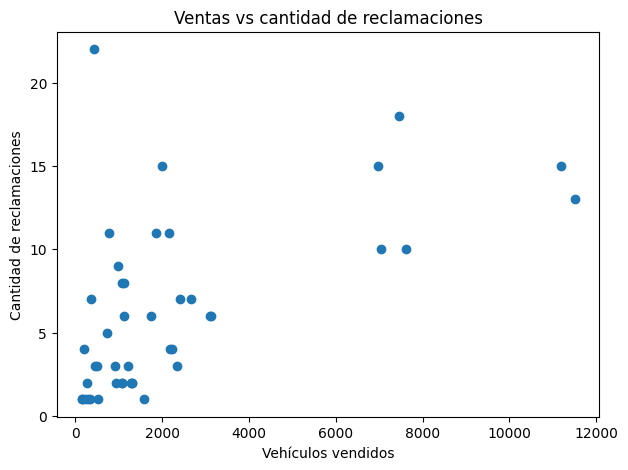

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dataset_integrado["ventas"],
    dataset_integrado["cantidad_quejas"]
)

plt.title("Ventas vs cantidad de reclamaciones")
plt.xlabel("Vehículos vendidos")
plt.ylabel("Cantidad de reclamaciones")
plt.show()


### Lo que vemos

Las marcas no están expuestas al mismo volumen de ventas.

Por eso una marca con más reclamaciones no necesariamente tiene una relación reclamaciones/ventas más alta.

El siguiente paso es justamente calcular esa relación de una forma comparable.


## 30. Revisar la distribución del indicador


count    44.00
mean      5.66
std       8.28
min       0.63
25%       1.85
50%       2.94
75%       6.65
max      51.64
Name: reclamos_por_1000_ventas, dtype: float64

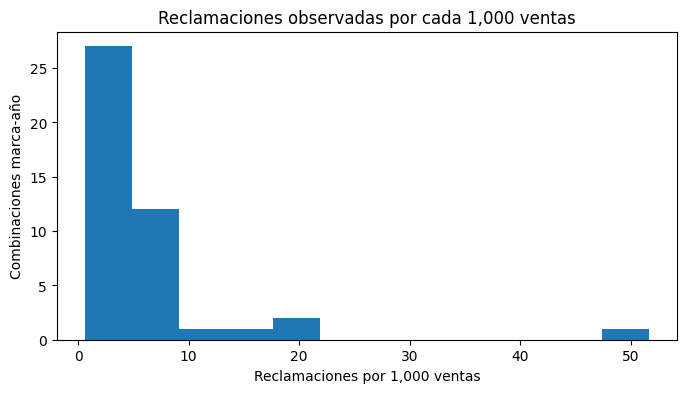

In [40]:
display(
    dataset_integrado["reclamos_por_1000_ventas"]
    .describe()
    .round(2)
)

plt.figure(figsize=(8, 4))
plt.hist(
    dataset_integrado["reclamos_por_1000_ventas"],
    bins=12
)
plt.title("Reclamaciones observadas por cada 1,000 ventas")
plt.xlabel("Reclamaciones por 1,000 ventas")
plt.ylabel("Combinaciones marca-año")
plt.show()


### Lo que encontramos

La distribución tiene algunos valores altos.

Por eso no escogemos límites manuales. Vamos a usar la propia distribución para formar tres grupos.


## 30.1 Ver las combinaciones marca-año con mayor indicador

Aquí ya usamos las reclamaciones por cada 1,000 ventas.

No lo mostramos como una lista de "mejores" o "peores" marcas. Solo queremos ver cuáles combinaciones marca-año tienen los valores más altos dentro de nuestros datos.


,anio,marca_std,reclamos_por_1000_ventas,marca_anio
3,2024,CHEVROLET,51.64,CHEVROLET - 2024
36,2025,MG,19.66,MG - 2025
34,2025,MAXUS,19.05,MAXUS - 2025
23,2025,CHEVROLET,14.10,CHEVROLET - 2025
22,2025,CHERY,9.25,CHERY - 2025
31,2025,KAIYI,7.50,KAIYI - 2025
30,2025,JETOUR,7.50,JETOUR - 2025
39,2025,OMODA,7.19,OMODA - 2025
26,2025,GAC MOTOR,7.10,GAC MOTOR - 2025
43,2025,VOLVO,6.90,VOLVO - 2025


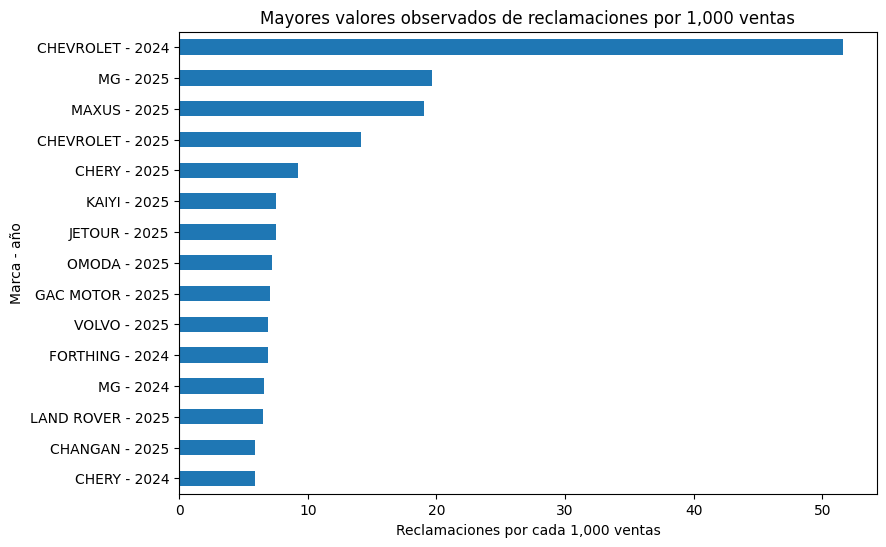

In [41]:
top_indicador = (
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "reclamos_por_1000_ventas"
        ]
    ]
    .assign(
        marca_anio=lambda x:
            x["marca_std"] + " - " + x["anio"].astype(str)
    )
    .sort_values(
        "reclamos_por_1000_ventas",
        ascending=False
    )
    .head(15)
)

display(top_indicador.round(2))

top_indicador.sort_values(
    "reclamos_por_1000_ventas"
).plot(
    x="marca_anio",
    y="reclamos_por_1000_ventas",
    kind="barh",
    figsize=(9, 6),
    legend=False
)

plt.title("Mayores valores observados de reclamaciones por 1,000 ventas")
plt.xlabel("Reclamaciones por cada 1,000 ventas")
plt.ylabel("Marca - año")
plt.show()


### Lo que vemos

Cuando usamos el indicador normalizado, el orden cambia respecto al simple conteo de reclamaciones.

Eso es justamente lo que queríamos comprobar con la unión de ACODECO y ADAP: el volumen de ventas cambia la forma de interpretar las reclamaciones.


# PARTE H — CREAR EL NIVEL DE RIESGO RELATIVO

para explorar los datos usamos terciles

- tercio de abajo → Bajo
- tercio del medio → Medio
- tercio de arriba → Alto

esto nos sirve para comparar como se comportan las variables entre los tres niveles

algo importante
estos cortes usando las 44 filas completas son solo para explorar y hacer las graficas

cuando entrenamos el modelo los cortes se vuelven a sacar usando solamente lo que quedo en entrenamiento
asi la parte que estamos evaluando no ayuda a crear su propia respuesta


## 31. Calcular los cortes para la exploracion

primero los calculamos con todo el conjunto solo para poder hacer las graficas y comparaciones de esta parte
mas adelante en el modelo los vamos a recalcular dentro de cada entrenamiento


In [42]:
corte_bajo = dataset_integrado[
    "reclamos_por_1000_ventas"
].quantile(1/3)

corte_alto = dataset_integrado[
    "reclamos_por_1000_ventas"
].quantile(2/3)

print("Corte Bajo/Medio:", round(corte_bajo, 2))
print("Corte Medio/Alto:", round(corte_alto, 2))


Corte Bajo/Medio: 1.92
,Corte Medio/Alto: 5.7


Con los datos actuales los cortes quedan aproximadamente en:

- Bajo: hasta **1.92**
- Medio: más de **1.92** y hasta **5.70**
- Alto: más de **5.70**

Estos valores no son límites oficiales. Salen de nuestros datos.


## 32. Crear el nivel de riesgo para la exploracion

esta columna nos ayuda a explorar el conjunto completo
no sera una etiqueta fija que le pasamos al modelo durante toda la validacion


In [43]:
dataset_integrado["Nivel_Riesgo_Relativo"] = pd.qcut(
    dataset_integrado["reclamos_por_1000_ventas"],
    q=3,
    labels=["Bajo", "Medio", "Alto"]
)

display(
    dataset_integrado[
        [
            "anio",
            "marca_std",
            "cantidad_quejas",
            "ventas",
            "reclamos_por_1000_ventas",
            "Nivel_Riesgo_Relativo"
        ]
    ]
    .sort_values("reclamos_por_1000_ventas")
    .round(2)
)


,anio,marca_std,cantidad_quejas,ventas,reclamos_por_1000_ventas,Nivel_Riesgo_Relativo
11,2024,ISUZU,1,1584.0,0.63,Bajo
41,2025,TOYOTA,13,11507.0,1.13,Bajo
8,2024,GEELY,3,2345.0,1.28,Bajo
32,2025,KIA,10,7626.0,1.31,Bajo
19,2024,TOYOTA,15,11189.0,1.34,Bajo
10,2024,HYUNDAI,10,7048.0,1.42,Bajo
25,2025,FORD,2,1315.0,1.52,Bajo
5,2024,FORD,2,1299.0,1.54,Bajo
35,2025,MAZDA,2,1275.0,1.57,Bajo
16,2024,MITSUBISHI,4,2233.0,1.79,Bajo


## 33. Ver cuántos quedaron en cada grupo


Nivel_Riesgo_Relativo
Bajo     15
Medio    14
Alto     15
Name: count, dtype: int64

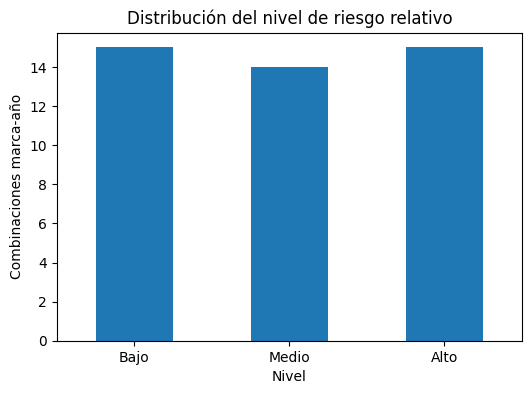

In [44]:
orden_riesgo = ["Bajo", "Medio", "Alto"]

conteo_riesgo = (
    dataset_integrado["Nivel_Riesgo_Relativo"]
    .value_counts()
    .reindex(orden_riesgo)
)

display(conteo_riesgo)

conteo_riesgo.plot(kind="bar", figsize=(6, 4))
plt.title("Distribución del nivel de riesgo relativo")
plt.xlabel("Nivel")
plt.ylabel("Combinaciones marca-año")
plt.xticks(rotation=0)
plt.show()


### Lo que encontramos

Quedan:

- Bajo: 15
- Medio: 14
- Alto: 15

La variable objetivo queda bastante equilibrada.


## 34. Comparar una misma marca entre 2024 y 2025

Una marca no tiene que quedar siempre en la misma categoría. El nivel se calcula por año.


In [45]:
comparacion_anual = dataset_integrado.pivot_table(
    index="marca_std",
    columns="anio",
    values=[
        "reclamos_por_1000_ventas",
        "Nivel_Riesgo_Relativo"
    ],
    aggfunc="first"
)

display(comparacion_anual)


Nivel_Riesgo_Relativo        reclamos_por_1000_ventas           
anio                        2024   2025                     2024       2025
marca_std                                                                  
BMW                         Bajo    NaN                 1.879699        NaN
CHANGAN                    Medio   Alto                 3.456221   5.933118
CHERY                       Alto   Alto                 5.893910   9.249743
CHEVROLET                   Alto   Alto                51.643192  14.102564
DONG FENG                  Medio  Medio                 2.148228   3.311258
FORD                        Bajo   Bajo                 1.539646   1.520913
FORTHING                    Alto    NaN                 6.877579        NaN
GAC MOTOR                  Medio   Alto                 5.314438   7.098492
GEELY                       Bajo   Bajo                 1.279318   1.912046
HONDA                      Medio   Bajo                 2.463054   1.860465
HYUNDAI                     Bajo  Medio                 1.418842   2.147459
ISUZU                       Bajo    NaN                 0.631313        NaN
JAC                        Medio    NaN                 4.255319        NaN
JETOUR                       NaN   Alto                      NaN   7.503752
KAIYI                        NaN   Alto                      NaN   7.504690
KIA                        Medio   Bajo                 2.413839   1.311303
LAND ROVER                   NaN   Alto                      NaN   6.493506
MAXUS                        NaN   Alto                      NaN  19.047619
MAZDA                       Bajo   Bajo                 1.857010   1.568627
MG                          Alto   Alto                 6.578947  19.662921
MITSUBISHI                  Bajo   Bajo                 1.791312   1.830664
NISSAN                     Medio  Medio                 2.896152   5.078486
OMODA                        NaN   Alto                      NaN   7.194245
SUZUKI                     Medio  Medio                 2.634550   1.939237
TOYOTA                      Bajo   Bajo                 1.340602   1.129747
VOLKSWAGEN                 Medio  Medio                 2.985075   3.311258
VOLVO                        NaN   Alto                      NaN   6.896552

## 34.1 Comparar 2024 y 2025 en las marcas que aparecen en ambos años

Para que la comparación sea más justa, aquí mostramos solamente marcas que tienen información integrada en los dos años.


anio,2024,2025
marca_std,,
MG,6.58,19.66
CHEVROLET,51.64,14.10
CHERY,5.89,9.25
GAC MOTOR,5.31,7.10
CHANGAN,3.46,5.93
NISSAN,2.90,5.08
VOLKSWAGEN,2.99,3.31
DONG FENG,2.15,3.31
HYUNDAI,1.42,2.15


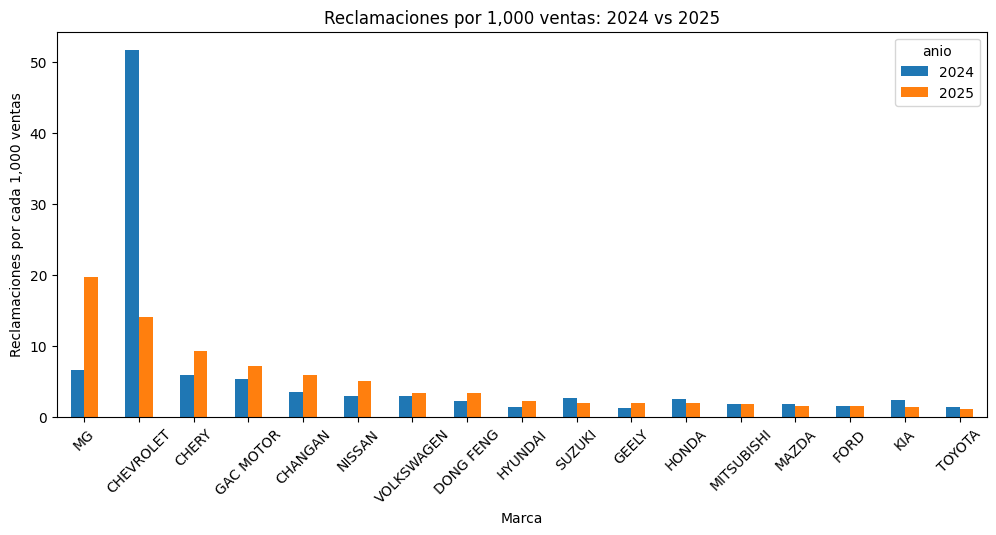

In [46]:
marcas_dos_anios = (
    dataset_integrado
    .groupby("marca_std")["anio"]
    .nunique()
)

marcas_dos_anios = marcas_dos_anios[
    marcas_dos_anios == 2
].index

comparacion_dos_anios = (
    dataset_integrado[
        dataset_integrado["marca_std"].isin(marcas_dos_anios)
    ]
    .pivot(
        index="marca_std",
        columns="anio",
        values="reclamos_por_1000_ventas"
    )
    .sort_values(2025, ascending=False)
)

display(comparacion_dos_anios.round(2))

comparacion_dos_anios.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Reclamaciones por 1,000 ventas: 2024 vs 2025")
plt.xlabel("Marca")
plt.ylabel("Reclamaciones por cada 1,000 ventas")
plt.xticks(rotation=45)
plt.show()


### Lo que vemos

Una misma marca puede subir o bajar de un año a otro.

Por eso el nivel de riesgo lo estamos tratando como **marca-año**, no como una etiqueta permanente de la marca.


## 34.2 Algo importante que vimos con el tamaño de las marcas

aqui encontramos algo que tenemos que dejar bien explicado

nuestro indicador divide reclamaciones entre ventas

entonces cuando una marca vende poco unas pocas reclamaciones pueden hacer que el numero por cada 1,000 ventas suba bastante

esto no quiere decir automaticamente que una marca pequeña sea peor
es una consecuencia de trabajar con un cociente cuando el denominador es pequeño


In [47]:
mediana_ventas_riesgo = (
    dataset_integrado
    .groupby("Nivel_Riesgo_Relativo", observed=False)["ventas"]
    .median()
    .reindex(["Bajo", "Medio", "Alto"])
)

display(mediana_ventas_riesgo)

corr_log = np.corrcoef(
    np.log(dataset_integrado["ventas"]),
    np.log(dataset_integrado["reclamos_por_1000_ventas"])
)[0, 1]

print("Correlacion entre log(ventas) y log(indicador):", round(corr_log, 2))


Nivel_Riesgo_Relativo
Bajo     2185.0
Medio    1477.0
Alto      509.0
Name: ventas, dtype: float64

Correlacion entre log(ventas) y log(indicador): -0.6


### Lo que encontramos

las ventas medianas quedan mas o menos asi

- Bajo → **2,185**
- Medio → **1,477**
- Alto → **509**

tambien la correlacion entre `log(ventas)` y `log(reclamos_por_1000_ventas)` queda cerca de **-0.60**

lo que vemos es que el indicador tiende a subir cuando las ventas son menores

por eso no podemos leer Alto como si automaticamente significara que esa marca es peor
tenemos que decir que el tamaño de la marca tambien influye en el indicador


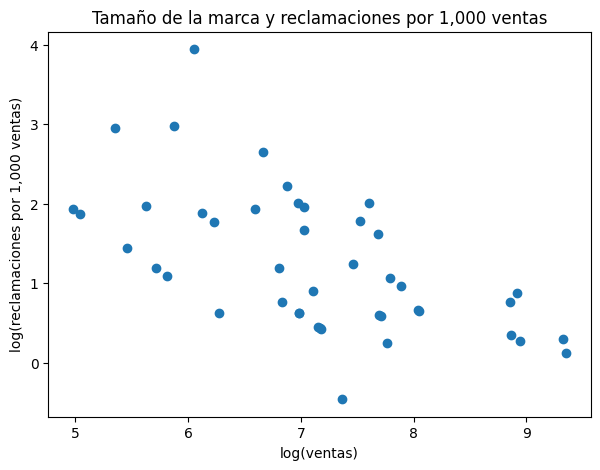

In [48]:
plt.figure(figsize=(7, 5))
plt.scatter(
    np.log(dataset_integrado["ventas"]),
    np.log(dataset_integrado["reclamos_por_1000_ventas"])
)
plt.title("Tamaño de la marca y reclamaciones por 1,000 ventas")
plt.xlabel("log(ventas)")
plt.ylabel("log(reclamaciones por 1,000 ventas)")
plt.show()


## 34.3 Tabla final de la clasificacion

aqui quisimos dejar todas las 44 combinaciones con su resultado en una sola tabla

asi podemos ver la marca el año las ventas las reclamaciones el indicador y el nivel que le tocó

la tabla está ordenada de mayor a menor indicador para que podamos comparar los casos

**ojo** este es el nivel exploratorio que armamos usando las 44 filas completas
cuando evaluamos los modelos los cortes se calculan otra vez solo con el entrenamiento

In [49]:
tabla_clasificacion = (
    dataset_integrado[
        ["marca_std", "anio", "ventas", "cantidad_quejas",
         "reclamos_por_1000_ventas", "Nivel_Riesgo_Relativo"]
    ]
    .rename(columns={
        "marca_std": "Marca",
        "anio": "Año",
        "ventas": "Ventas",
        "cantidad_quejas": "Reclamaciones",
        "reclamos_por_1000_ventas": "Reclamaciones por 1000 ventas",
        "Nivel_Riesgo_Relativo": "Nivel"
    })
    .sort_values("Reclamaciones por 1000 ventas", ascending=False)
    .reset_index(drop=True)
)
tabla_clasificacion.index = tabla_clasificacion.index + 1

assert len(tabla_clasificacion) == 44
print("Las 44 combinaciones marca-año con su clasificacion exploratoria")
with pd.option_context("display.max_rows", 50, "display.max_columns", None):
    display(tabla_clasificacion.round(2))

Las 44 combinaciones marca-año con su clasificacion exploratoria


,Marca,Año,Ventas,Reclamaciones,Reclamaciones por 1000 ventas,Nivel
1,CHEVROLET,2024,426.0,22,51.64,Alto
2,MG,2025,356.0,7,19.66,Alto
3,MAXUS,2025,210.0,4,19.05,Alto
4,CHEVROLET,2025,780.0,11,14.10,Alto
5,CHERY,2025,973.0,9,9.25,Alto
6,KAIYI,2025,1066.0,8,7.50,Alto
7,JETOUR,2025,1999.0,15,7.50,Alto
8,OMODA,2025,278.0,2,7.19,Alto
9,GAC MOTOR,2025,1127.0,8,7.10,Alto
10,VOLVO,2025,145.0,1,6.90,Alto


## 34.4 Resumen de lo que quedo en cada nivel

para no quedarnos solo con una tabla larga juntamos los resultados por Bajo Medio y Alto

asi vemos cuantos casos hay en cada grupo y como se comporta el indicador dentro de ellos

In [50]:
resumen_clasificacion = (
    dataset_integrado
    .groupby("Nivel_Riesgo_Relativo", observed=False)
    .agg(
        Combinaciones=("marca_std", "size"),
        Ventas_medianas=("ventas", "median"),
        Indicador_minimo=("reclamos_por_1000_ventas", "min"),
        Indicador_mediano=("reclamos_por_1000_ventas", "median"),
        Indicador_maximo=("reclamos_por_1000_ventas", "max")
    )
    .reindex(["Bajo", "Medio", "Alto"])
    .reset_index()
    .rename(columns={"Nivel_Riesgo_Relativo": "Nivel"})
)
resumen_clasificacion["Porcentaje"] = (
    resumen_clasificacion["Combinaciones"] / len(dataset_integrado) * 100
)
display(resumen_clasificacion.round(2))

,Nivel,Combinaciones,Ventas_medianas,Indicador_minimo,Indicador_mediano,Indicador_maximo,Porcentaje
0,Bajo,15,2185.0,0.63,1.54,1.91,34.09
1,Medio,14,1477.0,1.94,2.94,5.31,31.82
2,Alto,15,509.0,5.89,7.19,51.64,34.09


### Lo que encontramos

quedaron **15 en Bajo 14 en Medio y 15 en Alto**

esta distribucion es parecida entre los tres niveles porque los construimos usando terciles

algo que tambien se nota en el resumen es que las ventas medianas bajan entre Bajo y Alto

eso refuerza la advertencia que vimos antes
el indicador depende bastante de cuantas unidades vendio la marca y no se debe leer como si Alto significara automaticamente peor calidad

## 34.5 Ver los indicadores mas altos y mas bajos

miramos algunos ejemplos concretos para entender mejor las diferencias

los mostramos con las ventas y el numero de reclamaciones para no sacar conclusiones viendo solamente el indicador

In [51]:
print("Diez combinaciones con los indicadores mas altos")
display(tabla_clasificacion.head(10).round(2))

print("Diez combinaciones con los indicadores mas bajos")
display(tabla_clasificacion.tail(10).sort_values(
    "Reclamaciones por 1000 ventas"
).round(2))

Diez combinaciones con los indicadores mas altos


,Marca,Año,Ventas,Reclamaciones,Reclamaciones por 1000 ventas,Nivel
1,CHEVROLET,2024,426.0,22,51.64,Alto
2,MG,2025,356.0,7,19.66,Alto
3,MAXUS,2025,210.0,4,19.05,Alto
4,CHEVROLET,2025,780.0,11,14.10,Alto
5,CHERY,2025,973.0,9,9.25,Alto
6,KAIYI,2025,1066.0,8,7.50,Alto
7,JETOUR,2025,1999.0,15,7.50,Alto
8,OMODA,2025,278.0,2,7.19,Alto
9,GAC MOTOR,2025,1127.0,8,7.10,Alto
10,VOLVO,2025,145.0,1,6.90,Alto


Diez combinaciones con los indicadores mas bajos


,Marca,Año,Ventas,Reclamaciones,Reclamaciones por 1000 ventas,Nivel
44,ISUZU,2024,1584.0,1,0.63,Bajo
43,TOYOTA,2025,11507.0,13,1.13,Bajo
42,GEELY,2024,2345.0,3,1.28,Bajo
41,KIA,2025,7626.0,10,1.31,Bajo
40,TOYOTA,2024,11189.0,15,1.34,Bajo
39,HYUNDAI,2024,7048.0,10,1.42,Bajo
38,FORD,2025,1315.0,2,1.52,Bajo
37,FORD,2024,1299.0,2,1.54,Bajo
36,MAZDA,2025,1275.0,2,1.57,Bajo
35,MITSUBISHI,2024,2233.0,4,1.79,Bajo


## 34.6 Grafica de las 44 combinaciones marca-año

en esta grafica mostramos todas las observaciones ordenadas por reclamaciones por cada 1,000 ventas

los cortes son los exploratorios que sacamos con el conjunto completo
las barras representan el indicador observado no las predicciones de los modelos

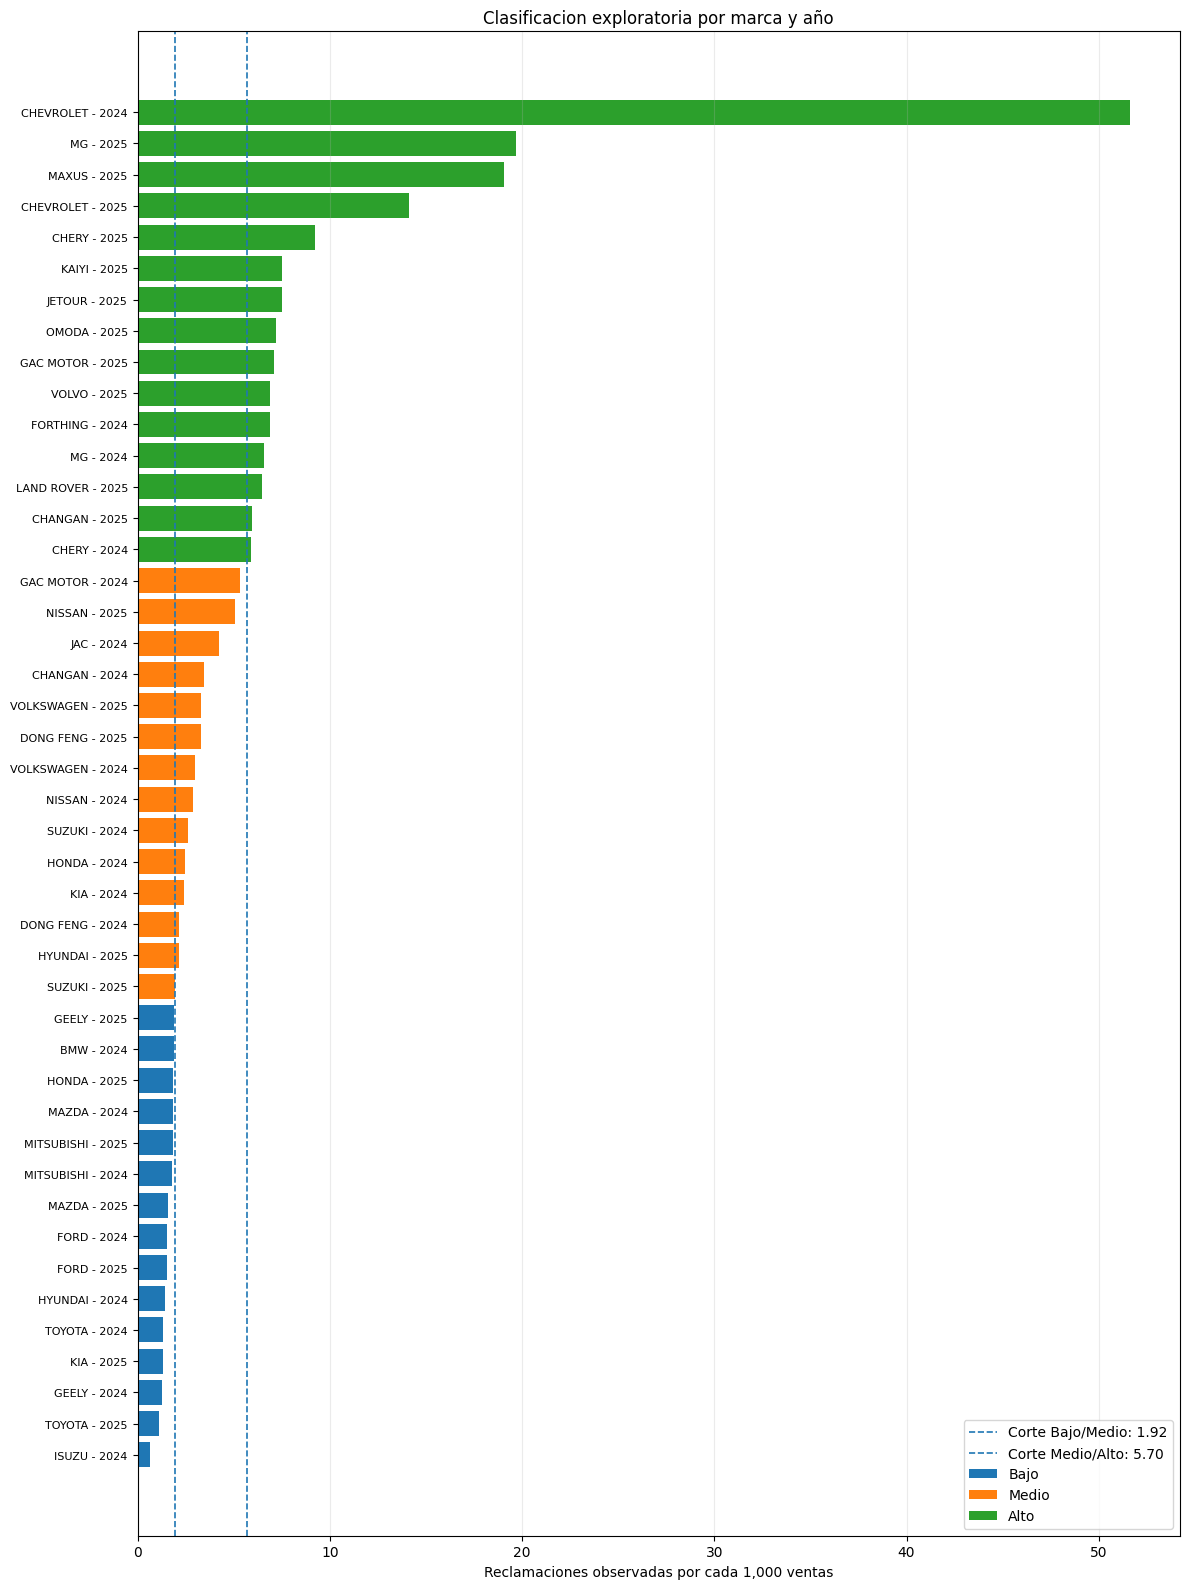

In [52]:
grafica_clasificacion = (
    dataset_integrado
    .sort_values("reclamos_por_1000_ventas")
    .reset_index(drop=True)
)
posiciones = np.arange(len(grafica_clasificacion))
niveles_grafica = grafica_clasificacion["Nivel_Riesgo_Relativo"].astype(str)
etiquetas = (
    grafica_clasificacion["marca_std"].astype(str)
    + " - "
    + grafica_clasificacion["anio"].astype(str)
)

fig, ax = plt.subplots(figsize=(12, 16))
for nivel in ["Bajo", "Medio", "Alto"]:
    seleccion = (niveles_grafica == nivel).to_numpy()
    ax.barh(
        posiciones[seleccion],
        grafica_clasificacion.loc[seleccion, "reclamos_por_1000_ventas"],
        label=nivel
    )

ax.axvline(corte_bajo, linestyle="--", linewidth=1.2,
           label=f"Corte Bajo/Medio: {corte_bajo:.2f}")
ax.axvline(corte_alto, linestyle="--", linewidth=1.2,
           label=f"Corte Medio/Alto: {corte_alto:.2f}")
ax.set_yticks(posiciones)
ax.set_yticklabels(etiquetas, fontsize=8)
ax.set_xlabel("Reclamaciones observadas por cada 1,000 ventas")
ax.set_title("Clasificacion exploratoria por marca y año")
ax.legend()
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

### Que nos dicen la tabla y la grafica sobre la pregunta del proyecto

si pudimos usar las ventas y las reclamaciones juntas para construir un indicador por marca-año
y con ese indicador ordenar las 44 combinaciones en Bajo Medio y Alto

eso responde a la parte de la pregunta sobre si podemos **clasificar el comportamiento relativo observado**

pero no demuestra que una marca en Alto tenga necesariamente vehiculos de peor calidad
ni que el modelo pueda predecir con seguridad las reclamaciones futuras

tambien vimos que el tamaño de la marca influye bastante
por eso mostramos siempre las ventas y las reclamaciones al lado del nivel
y mas adelante validamos los modelos por marca sin escoger un ganador a la fuerza

# PARTE I — TABLA DESCRIPTIVA

Aquí sacamos los números que usamos en el white paper.


In [53]:
variables_numericas = [
    "ventas",
    "cantidad_quejas",
    "monto_promedio",
    "reclamos_por_1000_ventas"
]

estadisticos = (
    dataset_integrado[variables_numericas]
    .agg(["mean", "median", "min", "max"])
    .T
)

estadisticos["pct_faltantes"] = (
    dataset_integrado[variables_numericas]
    .isna()
    .mean()
    .mul(100)
)

display(estadisticos.round(2))


,mean,median,min,max,pct_faltantes
ventas,2228.55,1173.50,145.00,11507.00,0.0
cantidad_quejas,6.23,4.50,1.00,22.00,0.0
monto_promedio,17966.09,19037.80,269.69,29500.00,0.0
reclamos_por_1000_ventas,5.66,2.94,0.63,51.64,0.0


# Antes del modelo — como vamos a trabajar con nuestras 44 observaciones

ya tenemos definido el conjunto del modelo
son **44 combinaciones marca-año**

sabemos que no es un conjunto grande
pero es el que sale correctamente al unir ACODECO y ADAP

por eso vamos con cuidado

- usamos modelos sencillos
- no hacemos una sola division y ya
- repetimos las pruebas
- comparamos con una referencia basica
- miramos Accuracy y tambien F1 macro

aqui ya no estamos viendo si las 44 sirven o no
**estas 44 son las observaciones del modelo**

lo que queremos ver ahora es cuanto podemos aprender con ellas


# PARTE J — Primer avance del modelo

nuestro dataset para esta parte tiene **44 observaciones marca-año**

con esas 44 filas hacemos un primer avance del modelo de clasificacion

todavia no lo llamamos modelo final
porque queremos seguir revisando variables y resultados

### Algo que tenemos que cuidar

`Nivel_Riesgo_Relativo` se construyo usando

- `cantidad_quejas`
- `ventas`
- `reclamos_por_1000_ventas`

por eso esas tres no las usamos como entrada del modelo

si las usamos seria casi como darle la respuesta

entonces usamos otras caracteristicas de las reclamaciones para ver si ayudan a diferenciar Bajo Medio y Alto


## 35. Elegir las variables que vamos a usar

antes teniamos siete variables pero vimos que algunas estaban diciendo casi lo mismo

por eso aqui hacemos una limpieza antes de entrenar


In [54]:
# Recortamos las variables porque encontramos dos pares que se parecen mucho
# monto_promedio con monto_mediano ~ 0.94
# pct_garantia con pct_servicio ~ -0.79

variables_modelo = [
    "monto_promedio",
    "pct_garantia",
    "pct_falta_info",
    "motivos_distintos",
    "anio"
]

X = dataset_integrado[variables_modelo].copy()
indicador = dataset_integrado["reclamos_por_1000_ventas"].copy()
grupos = dataset_integrado["marca_std"].copy()

# Esta etiqueta se usa solo para repartir de forma parecida los folds del StratifiedKFold
# las etiquetas reales de entrenamiento y evaluacion se vuelven a calcular dentro de cada fold
y_exploratorio = dataset_integrado["Nivel_Riesgo_Relativo"].astype(str)

print("Filas para el modelo:", len(X))
print("Variables:", variables_modelo)
print("Marcas distintas:", grupos.nunique())


Filas para el modelo: 44
,Variables: ['monto_promedio', 'pct_garantia', 'pct_falta_info', 'motivos_distintos', 'anio']
,Marcas distintas: 27


### Que variables dejamos

nos quedamos con cinco

- `monto_promedio`
- `pct_garantia`
- `pct_falta_info`
- `motivos_distintos`
- `anio`

quitamos `monto_mediano` porque estaba muy parecido a `monto_promedio`
la correlacion era como de 0.94

tambien quitamos `pct_servicio`
tenia una relacion fuerte con `pct_garantia` como de -0.79 y los dos salen del mismo total de motivos

no escogimos estas cinco porque dieran mejor Accuracy
lo hicimos para no darle al modelo informacion tan repetida


## 36. Primero revisar el problema de las marcas repetidas

este fue uno de los cambios mas importantes

17 marcas aparecen en 2024 y tambien en 2025
eso hace que 34 de las 44 filas tengan otra fila de la misma marca

y en 12 de esas 17 marcas el nivel queda igual en los dos años

con la validacion que teniamos antes podia pasar esto

`TOYOTA 2024` entrenando y `TOYOTA 2025` validando

aunque no sea la misma fila el modelo ya vio otra observacion de Toyota

por eso ahora tambien usamos validaciones donde la marca completa se mantiene junta


In [55]:
marcas_repetidas = (
    dataset_integrado
    .groupby("marca_std")
    .filter(lambda x: x["anio"].nunique() == 2)
)

resumen_marcas_repetidas = (
    marcas_repetidas
    .groupby("marca_std")["Nivel_Riesgo_Relativo"]
    .nunique()
)

print("Marcas que aparecen en los dos años:", len(resumen_marcas_repetidas))
print("Filas que pertenecen a esas marcas:", len(marcas_repetidas))
print("Marcas que conservan el mismo nivel:", (resumen_marcas_repetidas == 1).sum())


Marcas que aparecen en los dos años: 17
,Filas que pertenecen a esas marcas: 34
,Marcas que conservan el mismo nivel: 12


## 37. Las tres formas de validar que vamos a comparar

ojo aqui
estas tres cosas no son modelos
son formas de separar entrenamiento y validacion

### StratifiedKFold

trata de repartir Bajo Medio y Alto de forma parecida entre los grupos

el problema es que una misma marca puede quedar en entrenamiento y tambien en validacion

### GroupKFold

aqui usamos `marca_std` como grupo

si Toyota queda validando ninguna fila de Toyota queda entrenando

### Leave-One-Brand-Out

aqui sacamos una marca completa
entrenamos con las demas y probamos con la marca que dejamos afuera

despues hacemos lo mismo con cada marca

la idea es ver si las conclusiones cambian cuando somos mas estrictos con la marca


## 38. Los cortes de Bajo Medio y Alto salen solo del entrenamiento

antes sacabamos los terciles una sola vez con las 44 filas

ahora en cada vuelta hacemos esto

1. agarramos solo lo que quedo para entrenar
2. ahi sacamos los dos cortes
3. con esos cortes creamos Bajo Medio y Alto en entrenamiento
4. esos mismos cortes se usan despues en validacion

asi las filas que estamos evaluando no participan en la creacion de los cortes


In [56]:
from sklearn.model_selection import StratifiedKFold, GroupKFold, LeaveOneGroupOut
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


def crear_niveles(valores, corte_1, corte_2):
    return pd.cut(
        valores,
        bins=[-np.inf, corte_1, corte_2, np.inf],
        labels=["Bajo", "Medio", "Alto"],
        include_lowest=True
    ).astype(str)


def evaluar_modelo(modelo, cv, nombre_esquema, usar_grupos=False):
    reales = np.empty(len(X), dtype=object)
    predicciones = np.empty(len(X), dtype=object)
    cortes = []

    if usar_grupos:
        divisiones = cv.split(X, y_exploratorio, groups=grupos)
    else:
        divisiones = cv.split(X, y_exploratorio)

    for fold, (idx_train, idx_test) in enumerate(divisiones, start=1):
        indicador_train = indicador.iloc[idx_train]
        indicador_test = indicador.iloc[idx_test]

        corte_1 = indicador_train.quantile(1/3)
        corte_2 = indicador_train.quantile(2/3)

        y_train = crear_niveles(indicador_train, corte_1, corte_2)
        y_test = crear_niveles(indicador_test, corte_1, corte_2)

        modelo_fold = clone(modelo)
        modelo_fold.fit(X.iloc[idx_train], y_train)
        pred = modelo_fold.predict(X.iloc[idx_test])

        reales[idx_test] = y_test
        predicciones[idx_test] = pred

        cortes.append({
            "Esquema": nombre_esquema,
            "Fold": fold,
            "Corte Bajo/Medio": corte_1,
            "Corte Medio/Alto": corte_2
        })

    return {
        "accuracy": accuracy_score(reales, predicciones),
        "f1_macro": f1_score(reales, predicciones, average="macro"),
        "reales": reales,
        "predicciones": predicciones,
        "cortes": pd.DataFrame(cortes)
    }


## 39. Modelos que vamos a comparar

para esta parte dejamos tres cosas sencillas

- una referencia basica
- Regresion Logistica
- Arbol de Decision pequeño

la referencia no es un modelo que queramos usar al final
solo nos sirve para saber cuanto obtendriamos con algo muy basico

la Regresion Logistica intenta separar Bajo Medio y Alto usando una combinacion de las variables

el Arbol va haciendo cortes tipo si una variable pasa cierto valor sigue por un lado y si no por otro

Random Forest lo habiamos probado antes
pero con 44 filas preferimos entender bien estos primero antes de seguir metiendo mas modelos


In [57]:
modelo_base = DummyClassifier(strategy="most_frequent")

modelo_logistico = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

modelo_arbol = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

modelos = {
    "Referencia basica": modelo_base,
    "Regresion Logistica": modelo_logistico,
    "Arbol": modelo_arbol
}


## 40. Ejecutar los tres esquemas

aqui corremos los mismos modelos con las tres formas de validacion

lo que queremos ver no es quien gana una sola vez
queremos ver si el resultado se mantiene cuando cambiamos la forma de separar los datos


In [58]:
esquemas = {
    "StratifiedKFold": (StratifiedKFold(n_splits=4, shuffle=True, random_state=42), False),
    "GroupKFold": (GroupKFold(n_splits=4), True),
    "Leave-One-Brand-Out": (LeaveOneGroupOut(), True)
}

resultados = []
detalle_resultados = {}
todos_los_cortes = []

for nombre_esquema, (cv, usar_grupos) in esquemas.items():
    detalle_resultados[nombre_esquema] = {}

    for nombre_modelo, modelo in modelos.items():
        resultado = evaluar_modelo(
            modelo,
            cv,
            nombre_esquema,
            usar_grupos=usar_grupos
        )

        detalle_resultados[nombre_esquema][nombre_modelo] = resultado

        resultados.append({
            "Esquema": nombre_esquema,
            "Modelo": nombre_modelo,
            "Accuracy": resultado["accuracy"],
            "F1_macro": resultado["f1_macro"]
        })

        if nombre_modelo == "Regresion Logistica":
            todos_los_cortes.append(resultado["cortes"])

resultados_validacion = pd.DataFrame(resultados)

display(
    resultados_validacion
    .pivot(index="Modelo", columns="Esquema", values="Accuracy")
    .round(3)
)

print()
print("F1 macro")
display(
    resultados_validacion
    .pivot(index="Modelo", columns="Esquema", values="F1_macro")
    .round(3)
)


Esquema,GroupKFold,Leave-One-Brand-Out,StratifiedKFold
Modelo,,,
Arbol,0.477,0.341,0.409
Referencia basica,0.341,0.341,0.318
Regresion Logistica,0.432,0.477,0.477



,F1 macro


Esquema,GroupKFold,Leave-One-Brand-Out,StratifiedKFold
Modelo,,,
Arbol,0.454,0.329,0.425
Referencia basica,0.169,0.169,0.161
Regresion Logistica,0.430,0.475,0.477


### Que cambia con esta revision

los numeros ya no tienen que quedar iguales a la version anterior

ahora cambiamos dos cosas

- pasamos de siete variables a cinco
- los cortes de los terciles salen dentro de cada entrenamiento

por eso todo se vuelve a calcular
no tratamos de forzar que salgan los numeros anteriores


## 41. Ver como cambian los cortes entre entrenamientos

como cada vuelta tiene un conjunto de entrenamiento un poco diferente
los cortes tampoco quedan exactamente iguales

esto nos ayuda a ver que con 44 filas hay bastante variacion


In [59]:
cortes_validacion = pd.concat(todos_los_cortes, ignore_index=True)

resumen_cortes = (
    cortes_validacion
    .groupby("Esquema")[["Corte Bajo/Medio", "Corte Medio/Alto"]]
    .agg(["min", "median", "max"])
)

display(resumen_cortes.round(2))


Corte Bajo/Medio              Corte Medio/Alto             
                                 min median   max              min median   max
Esquema                                                                        
GroupKFold                      1.86   1.90  2.45             3.72   5.71  6.52
Leave-One-Brand-Out             1.90   1.91  2.08             5.16   5.89  5.91
StratifiedKFold                 1.90   1.92  1.93             5.51   5.51  6.12

## 42. Mirar GroupKFold con mas detalle

GroupKFold nos interesa bastante porque no deja que una marca aparezca en entrenamiento y validacion al mismo tiempo

aqui miramos la matriz de confusion para ver en que niveles se equivocan mas la Regresion Logistica y el Arbol


In [60]:
for nombre_modelo in ["Regresion Logistica", "Arbol"]:
    res = detalle_resultados["GroupKFold"][nombre_modelo]

    matriz = pd.DataFrame(
        confusion_matrix(
            res["reales"],
            res["predicciones"],
            labels=["Bajo", "Medio", "Alto"]
        ),
        index=["Real Bajo", "Real Medio", "Real Alto"],
        columns=["Pred Bajo", "Pred Medio", "Pred Alto"]
    )

    print(nombre_modelo)
    display(matriz)


Regresion Logistica


,Pred Bajo,Pred Medio,Pred Alto
Real Bajo,6,5,4
Real Medio,5,5,4
Real Alto,2,5,8


Arbol


,Pred Bajo,Pred Medio,Pred Alto
Real Bajo,7,4,4
Real Medio,2,3,9
Real Alto,2,2,11


## 43. Que podemos concluir de los modelos por ahora

esta parte cambia la conclusion que teniamos antes

antes estabamos pensando seguir con Regresion Logistica porque en una prueba se veia mejor

ahora al validar por marca y tambien dejar una marca completa afuera vemos que el resultado cambia segun la forma de validar

con 44 observaciones una o dos filas cambian bastante el Accuracy

por eso todavia **no podemos decir que un modelo sea claramente mejor que el otro**

lo que si vemos es que los modelos quedan por encima de una referencia cercana a 0.33

parece que hay algo de señal en las variables
pero las diferencias entre Logistica y Arbol son pequeñas para el tamaño de muestra que tenemos

por ahora esa es la conclusion que mas sentido nos hace


## 44. Que significa esto para el proyecto

las 44 filas no son algo que tengamos que esconder

son lo que queda cuando unimos ACODECO y ADAP correctamente a nivel marca-año

podemos entrenar y comparar modelos con ellas
pero tenemos que ser prudentes con lo que afirmamos

por ahora no tenemos suficiente para decir que encontramos un ganador

si mas adelante conseguimos ventas mensuales de ADAP podriamos pasar a marca-mes
y ahi si aumentar observaciones sin inventar datos


# PARTE L — Por que las 44 filas siguen siendo nuestro dataset

tenemos 44 combinaciones marca-año porque ese es el nivel real en que podemos juntar reclamaciones y ventas

no queremos repetir la misma venta anual en muchas filas solo para aparentar mas datos

44 es una limitacion
pero tambien es el dato real del problema

con este tamaño podemos hacer una primera comparacion de modelos
solo que las diferencias pequeñas hay que tomarlas con cuidado


# PARTE M — LO QUE TENIAMOS HASTA AQUI

ya tenemos la integracion de ACODECO con ADAP y tambien aplicamos las correcciones de validacion que nos señalaron

ahora vamos a reunir los resultados que realmente salieron al ejecutar el cuaderno

la idea de esta parte es que no queden los numeros sueltos en diferentes celdas
queremos ver que encontramos en los datos y que nos dicen las pruebas de los modelos

# PARTE N — RESULTADOS Y HALLAZGOS QUE OBTUVIMOS

aqui reunimos los resultados de todo el trabajo

primero dejamos claro como llegamos al conjunto final y despues vemos que paso con los modelos

no estamos cambiando el analisis para que un modelo se vea mejor
vamos a mostrar lo que salio con las correcciones aplicadas

## 45. El recorrido de los datos en una sola tabla

empezamos con los archivos completos de ACODECO
fuimos revisando que reclamaciones eran comparables con las ventas de ADAP y despues resumimos por marca y año

esta tabla nos ayuda a ver todo el camino de una sola vez

In [61]:
resumen_recorrido = pd.DataFrame([
    {"Paso": "ACODECO 2024 y 2025 unidos", "Cantidad": len(acodeco)},
    {"Paso": "Departamento Vehículo a Motor", "Cantidad": len(vehiculos)},
    {"Paso": "Actividades de autos seleccionadas", "Cantidad": len(sector_autos)},
    {"Paso": "Agencia de autos + Automóvil", "Cantidad": len(reclamos_comparables)},
    {"Paso": "Reclamaciones con marca identificable", "Cantidad": int(identificables)},
    {"Paso": "Reclamaciones con match en ADAP", "Cantidad": len(reclamos_match)},
    {"Paso": "Observaciones finales marca-año", "Cantidad": len(dataset_integrado)}
])

display(resumen_recorrido)
print("Cobertura del match sobre las reclamaciones comparables:",
      f"{len(reclamos_match) / len(reclamos_comparables) * 100:.2f}%")
print("Marcas diferentes en el dataset final:", dataset_integrado["marca_std"].nunique())
print("Años incluidos:", sorted(dataset_integrado["anio"].unique().tolist()))

assert len(dataset_integrado) == 44
assert dataset_integrado[["anio", "marca_std"]].duplicated().sum() == 0

,Paso,Cantidad
0,ACODECO 2024 y 2025 unidos,3978
1,Departamento Vehículo a Motor,924
2,Actividades de autos seleccionadas,840
3,Agencia de autos + Automóvil,321
4,Reclamaciones con marca identificable,298
5,Reclamaciones con match en ADAP,274
6,Observaciones finales marca-año,44


Cobertura del match sobre las reclamaciones comparables: 85.36%
,Marcas diferentes en el dataset final: 27
,Años incluidos: [2024, 2025]


### Lo que entendimos de este recorrido

las 274 reclamaciones no se borraron al llegar a 44

lo que hicimos fue juntarlas por `marca + año` porque ADAP da las ventas a ese nivel

cada una de esas 44 filas es un caso del modelo y no una reclamacion individual

tambien hay que decir que este conjunto se construyo a partir de las marcas-año con reclamaciones que logramos emparejar
no incluye automaticamente todos los casos con cero reclamaciones

## 46. Que encontramos al crear el nivel de riesgo

la tasa que usamos fue reclamaciones observadas por cada 1,000 ventas del mismo año

con los datos completos sacamos los tres grupos solo para la exploracion
y para validar los modelos volvimos a sacar los cortes dentro de cada entrenamiento

In [62]:
resumen_niveles = (
    dataset_integrado["Nivel_Riesgo_Relativo"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto"])
    .rename_axis("Nivel")
    .reset_index(name="Combinaciones marca-año")
)
resumen_niveles["Porcentaje"] = (
    resumen_niveles["Combinaciones marca-año"] / len(dataset_integrado) * 100
).round(1)

display(resumen_niveles)
print("Corte exploratorio Bajo/Medio:", round(corte_bajo, 2))
print("Corte exploratorio Medio/Alto:", round(corte_alto, 2))

,Nivel,Combinaciones marca-año,Porcentaje
0,Bajo,15,34.1
1,Medio,14,31.8
2,Alto,15,34.1


Corte exploratorio Bajo/Medio: 1.92
,Corte exploratorio Medio/Alto: 5.7


### La advertencia que no podemos olvidar

Bajo Medio y Alto son niveles **relativos a nuestro conjunto**
no son una clasificacion oficial de calidad de cada marca

tambien vimos que las marcas con menos ventas pueden subir mas rapido en el indicador porque dividimos entre un numero pequeño

por eso encontramos medianas de ventas de 2185 en Bajo 1477 en Medio y 509 en Alto
la correlacion entre los logaritmos de ventas e indicador fue cercana a -0.60

esto no demuestra que las marcas pequeñas tengan vehiculos de peor calidad
solo nos dice que debemos interpretar el cociente con cuidado

## 47. Asi quedaron los resultados de las tres validaciones

aqui ponemos los tres modelos y los tres tipos de validacion en una misma tabla

**Accuracy** es la proporcion de casos que quedaron bien clasificados

**F1 macro** resume como le fue al modelo en Bajo Medio y Alto dando el mismo peso a las tres clases

la referencia basica nos sirve para comparar contra algo que casi no aprende

In [63]:
tabla_resultados_final = resultados_validacion.copy()
tabla_resultados_final["Aciertos de 44"] = (
    tabla_resultados_final["Accuracy"] * len(X)
).round().astype(int)
tabla_resultados_final["Accuracy (%)"] = (
    tabla_resultados_final["Accuracy"] * 100
).round(1)
tabla_resultados_final["F1 macro"] = tabla_resultados_final["F1_macro"].round(3)

orden_esquemas = ["StratifiedKFold", "GroupKFold", "Leave-One-Brand-Out"]
orden_modelos = ["Referencia basica", "Regresion Logistica", "Arbol"]

tabla_resultados_final["Esquema"] = pd.Categorical(
    tabla_resultados_final["Esquema"], categories=orden_esquemas, ordered=True
)
tabla_resultados_final["Modelo"] = pd.Categorical(
    tabla_resultados_final["Modelo"], categories=orden_modelos, ordered=True
)

display(
    tabla_resultados_final.sort_values(["Esquema", "Modelo"])[
        ["Esquema", "Modelo", "Aciertos de 44", "Accuracy (%)", "F1 macro"]
    ].reset_index(drop=True)
)

,Esquema,Modelo,Aciertos de 44,Accuracy (%),F1 macro
0,StratifiedKFold,Referencia basica,14,31.8,0.161
1,StratifiedKFold,Regresion Logistica,21,47.7,0.477
2,StratifiedKFold,Arbol,18,40.9,0.425
3,GroupKFold,Referencia basica,15,34.1,0.169
4,GroupKFold,Regresion Logistica,19,43.2,0.430
5,GroupKFold,Arbol,21,47.7,0.454
6,Leave-One-Brand-Out,Referencia basica,15,34.1,0.169
7,Leave-One-Brand-Out,Regresion Logistica,21,47.7,0.475
8,Leave-One-Brand-Out,Arbol,15,34.1,0.329


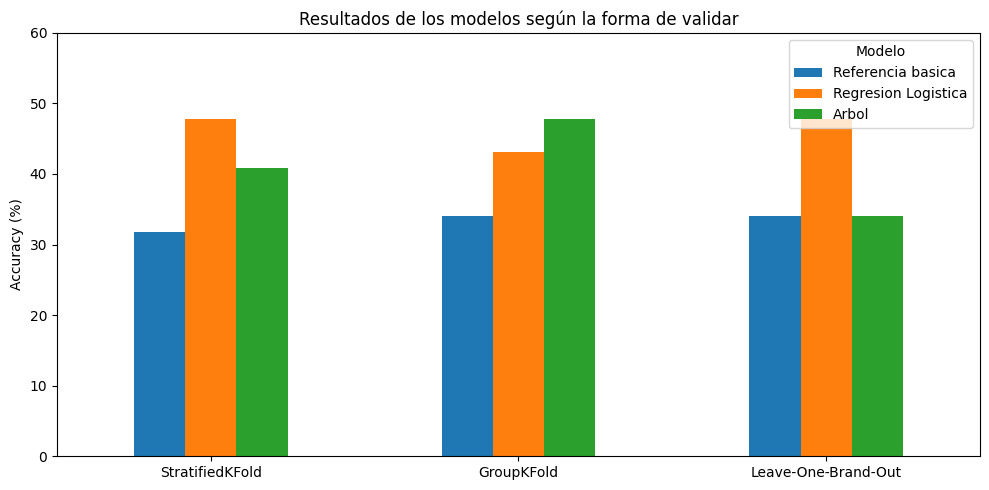

In [64]:
grafica_resultados = (
    resultados_validacion
    .pivot(index="Esquema", columns="Modelo", values="Accuracy")
    .reindex(orden_esquemas)[orden_modelos]
    .mul(100)
)
grafica_resultados.plot(kind="bar", figsize=(10, 5))
plt.title("Resultados de los modelos según la forma de validar")
plt.ylabel("Accuracy (%)")
plt.xlabel("")
plt.ylim(0, 60)
plt.xticks(rotation=0)
plt.legend(title="Modelo", loc="upper right")
plt.tight_layout()
plt.show()

### Que vimos al comparar

con StratifiedKFold la Regresion Logistica dio 47.7% y el Arbol 40.9%

con GroupKFold el Arbol dio 47.7% y la Logistica 43.2%

con Leave-One-Brand-Out la Logistica dio 47.7% y el Arbol 34.1%

la referencia basica quedo entre 31.8% y 34.1% segun la validacion

el resultado cambia cuando cambiamos la forma de evaluar
por eso ya no dejamos escrita la Logistica como si fuera la ganadora definitiva

estos son los resultados **con cinco variables y los terciles calculados dentro del entrenamiento**
por eso no tienen que coincidir exactamente con los numeros de la version anterior

## 48. Cuantos casos se clasificaron bien

como tenemos 44 observaciones queremos ver tambien los aciertos en cantidad de filas

asi se entiende mejor lo que significa pasar de 43% a 48%

In [65]:
aciertos_por_esquema = (
    tabla_resultados_final
    .pivot(index="Modelo", columns="Esquema", values="Aciertos de 44")
    .reindex(orden_modelos)[orden_esquemas]
)
display(aciertos_por_esquema)

Esquema,StratifiedKFold,GroupKFold,Leave-One-Brand-Out
Modelo,,,
Referencia basica,14,15,15
Regresion Logistica,21,19,21
Arbol,18,21,15


### Nuestra lectura

en GroupKFold la Logistica acerto 19 de 44 y el Arbol 21 de 44

son solo dos casos de diferencia

con una muestra tan pequeña no tiene sentido presentar esa diferencia como una victoria definitiva de un algoritmo

lo que podemos decir es que hay resultados por encima de la referencia en varias pruebas
pero todavia no tenemos evidencia suficiente para elegir un modelo con seguridad

## 49. Donde se equivocaron cuando separamos por marca

GroupKFold nos interesa mucho porque ninguna marca que esta validando aparece al mismo tiempo en entrenamiento

aqui revisamos cuantos Bajo Medio y Alto se clasificaron bien y en cuales se confundieron

In [66]:
from sklearn.metrics import classification_report

for nombre_modelo in ["Regresion Logistica", "Arbol"]:
    detalle = detalle_resultados["GroupKFold"][nombre_modelo]
    reporte_clases = classification_report(
        detalle["reales"],
        detalle["predicciones"],
        labels=["Bajo", "Medio", "Alto"],
        output_dict=True,
        zero_division=0
    )
    tabla_clases = pd.DataFrame(reporte_clases).T.loc[
        ["Bajo", "Medio", "Alto"], ["precision", "recall", "f1-score", "support"]
    ].round(3)
    print(nombre_modelo)
    display(tabla_clases)

Regresion Logistica


,precision,recall,f1-score,support
Bajo,0.462,0.400,0.429,15.0
Medio,0.333,0.357,0.345,14.0
Alto,0.500,0.533,0.516,15.0


Arbol


,precision,recall,f1-score,support
Bajo,0.636,0.467,0.538,15.0
Medio,0.333,0.214,0.261,14.0
Alto,0.458,0.733,0.564,15.0


### Lo que encontramos en las confusiones

el Arbol alcanzo mas aciertos en Alto que la Logistica dentro de GroupKFold
pero tambien confundio varios casos que eran Medio y los paso a Alto

esto nos muestra que mirar un solo porcentaje no alcanza
tenemos que mirar a que nivel se esta equivocando

y otra vez recordamos que son muy pocos casos para sacar conclusiones fuertes

## 50. Comprobamos que las marcas no se mezclen en GroupKFold

este fue el cambio principal que nos pidieron

hacemos una comprobacion adicional para confirmar que una marca que esta validando no aparezca tambien entrenando

In [67]:
cv_marca = GroupKFold(n_splits=4)
comprobacion_grupos = []

for numero, (entreno, valido) in enumerate(
    cv_marca.split(X, y_exploratorio, groups=grupos), start=1
):
    marcas_entreno = set(grupos.iloc[entreno])
    marcas_validacion = set(grupos.iloc[valido])
    compartidas = marcas_entreno.intersection(marcas_validacion)

    comprobacion_grupos.append({
        "Vuelta": numero,
        "Filas entrenamiento": len(entreno),
        "Filas validacion": len(valido),
        "Marcas compartidas": len(compartidas)
    })
    assert len(compartidas) == 0

display(pd.DataFrame(comprobacion_grupos))
print("Listo: ninguna marca aparece en ambos lados de una misma vuelta")

,Vuelta,Filas entrenamiento,Filas validacion,Marcas compartidas
0,1,33,11,0
1,2,33,11,0
2,3,33,11,0
3,4,33,11,0


Listo: ninguna marca aparece en ambos lados de una misma vuelta


# PARTE O — CONCLUSION DEL PROYECTO

## 51. Lo que si podemos decir

conseguimos integrar las reclamaciones de ACODECO con las ventas de ADAP
y obtuvimos 44 combinaciones marca-año para hacer el analisis

normalizar por ventas nos ayudo a no comparar solamente el numero bruto de reclamaciones

en la seccion 34.3 dejamos las 44 combinaciones con su nivel y en la 34.6 la grafica completa
asi mostramos el resultado que responde directamente a nuestra pregunta de clasificacion relativa

tambien encontramos que el indicador cambia bastante con el tamaño de las marcas
eso hay que decirlo siempre cuando mostremos los niveles Bajo Medio y Alto

en los modelos pasamos de siete variables a cinco para reducir informacion repetida
y evaluamos de tres maneras para no depender de una sola division de los datos

los resultados muestran algunos aciertos por encima de la referencia basica
pero el modelo que queda arriba cambia segun la forma de validar

por eso **no podemos decir todavia que encontramos el mejor algoritmo**

lo que tenemos es una primera fase de entrenamiento documentada
con sus resultados y sus limitaciones

## 52. Lo que debemos aclarar cuando presentemos el trabajo

los 44 casos corresponden a marca-año con reclamaciones emparejadas con ADAP
no representan automaticamente todas las marcas y meses con cero reclamaciones

el año de la reclamacion no necesariamente es el mismo año en que se compro el auto
por eso la tasa es un indicador exploratorio de reclamaciones observadas por ventas del mismo año
no una tasa oficial de fallas de los vehiculos

ademas el monto y los motivos se resumen de reclamaciones que ya ocurrieron
por ahora estamos clasificando y estudiando el comportamiento observado
no tenemos una prediccion validada de fallas futuras antes de que existan reclamaciones

si conseguimos ventas mensuales reales por marca y las podemos unir correctamente con los datos de ACODECO
podriamos probar una version marca-mes con mas observaciones
sin dividir artificialmente las ventas anuales entre doce

## 53. Nuestro cierre

el resultado mas importante no fue conseguir un numero alto de Accuracy

fue poder construir los datos de forma coherente revisar el indicador y corregir la forma de validar cuando vimos que las marcas se repetian entre años

con 44 observaciones estamos viendo una primera señal pero hay bastante variacion
asi que dejamos los resultados tal como salieron y no escogemos un modelo ganador a la fuerza

con eso cerramos tuvimos que cerrar el  proyecto

# PARTE P — Comprobación de entrenamiento, validación y prueba final

El formato del reporte final nos pide mostrar **la misma métrica** en entrenamiento, validación cruzada y una prueba que no haya participado en el ajuste. Esta es una evaluación **adicional** a los tres esquemas sobre las 44 filas que ya mostramos arriba; no deben mezclarse sus porcentajes.

Separamos una parte final por **marca completa** mediante `StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)`, usando el primer reparto: 33 combinaciones marca-año para entrenar y 11 para prueba. La estratificación usa únicamente los niveles exploratorios para intentar repartir las clases; la etiqueta real se recalcula con los cortes obtenidos **solo del conjunto de entrenamiento**. Ninguna marca aparece a la vez en entrenamiento y prueba.

Dentro de las 33 filas de entrenamiento, usamos `GroupKFold` con 4 partes. En cada vuelta recalculamos los terciles usando exclusivamente su entrenamiento. Mantenemos los mismos tres modelos y parámetros. El árbol es pequeño (`max_depth=3`, `min_samples_leaf=3`) como decisión conservadora antes de la evaluación; **no realizamos una búsqueda formal de hiperparámetros** ni elegimos valores viendo la prueba final. La Regresión Logística escala sus variables dentro de un Pipeline.

In [68]:
from sklearn.model_selection import StratifiedGroupKFold

separador_final = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
idx_entreno_final, idx_prueba_final = next(
    separador_final.split(X, y_exploratorio, groups=grupos)
)

X_entreno_final = X.iloc[idx_entreno_final]
X_prueba_final = X.iloc[idx_prueba_final]
tasa_entreno_final = indicador.iloc[idx_entreno_final]
tasa_prueba_final = indicador.iloc[idx_prueba_final]
grupos_entreno_final = grupos.iloc[idx_entreno_final]

corte_1_final = tasa_entreno_final.quantile(1/3)
corte_2_final = tasa_entreno_final.quantile(2/3)
y_entreno_final = crear_niveles(tasa_entreno_final, corte_1_final, corte_2_final)
y_prueba_final = crear_niveles(tasa_prueba_final, corte_1_final, corte_2_final)

assert len(X_entreno_final) == 33 and len(X_prueba_final) == 11
assert not set(grupos_entreno_final).intersection(set(grupos.iloc[idx_prueba_final]))
print('Entrenamiento:', len(X_entreno_final), 'filas;', grupos_entreno_final.nunique(), 'marcas')
print('Prueba final:', len(X_prueba_final), 'filas;', grupos.iloc[idx_prueba_final].nunique(), 'marcas')
print('Marcas compartidas: 0 | Semilla: 42')
print('Cortes calculados SOLO en entrenamiento:', round(corte_1_final, 3), round(corte_2_final, 3))
print('Distribución de clases en prueba:', y_prueba_final.value_counts().to_dict())

Entrenamiento: 33 filas; 21 marcas
,Prueba final: 11 filas; 6 marcas
,Marcas compartidas: 0 | Semilla: 42
,Cortes calculados SOLO en entrenamiento: 1.872 5.363
,Distribución de clases en prueba: {'Medio': 5, 'Alto': 4, 'Bajo': 2}


In [69]:
filas_evaluacion_final = []
modelos_entrenados_final = {}
matrices_prueba_final = {}
cv_interno_final = GroupKFold(n_splits=4)
orden_clases_final = ['Bajo', 'Medio', 'Alto']

for nombre, modelo in modelos.items():
    ajustado = clone(modelo)
    ajustado.fit(X_entreno_final, y_entreno_final)
    pred_entreno = ajustado.predict(X_entreno_final)
    pred_prueba = ajustado.predict(X_prueba_final)

    reales_cv, pred_cv = [], []
    for tr, val in cv_interno_final.split(X_entreno_final, groups=grupos_entreno_final):
        t_tr = tasa_entreno_final.iloc[tr]
        ct1, ct2 = t_tr.quantile(1/3), t_tr.quantile(2/3)
        y_tr = crear_niveles(t_tr, ct1, ct2)
        y_val = crear_niveles(tasa_entreno_final.iloc[val], ct1, ct2)
        temporal = clone(modelo)
        temporal.fit(X_entreno_final.iloc[tr], y_tr)
        reales_cv.extend(y_val)
        pred_cv.extend(temporal.predict(X_entreno_final.iloc[val]))

    modelos_entrenados_final[nombre] = ajustado
    matrices_prueba_final[nombre] = confusion_matrix(
        y_prueba_final, pred_prueba, labels=orden_clases_final
    )
    filas_evaluacion_final.append({
        'Modelo': nombre,
        'Accuracy entrenamiento': accuracy_score(y_entreno_final, pred_entreno),
        'Accuracy CV': accuracy_score(reales_cv, pred_cv),
        'Accuracy prueba': accuracy_score(y_prueba_final, pred_prueba),
        'F1 macro entrenamiento': f1_score(y_entreno_final, pred_entreno, labels=orden_clases_final, average='macro', zero_division=0),
        'F1 macro CV': f1_score(reales_cv, pred_cv, labels=orden_clases_final, average='macro', zero_division=0),
        'F1 macro prueba': f1_score(y_prueba_final, pred_prueba, labels=orden_clases_final, average='macro', zero_division=0)
    })

tabla_final_reporte = pd.DataFrame(filas_evaluacion_final)
display(tabla_final_reporte.round(3))


,Modelo,Accuracy entrenamiento,Accuracy CV,Accuracy prueba,F1 macro entrenamiento,F1 macro CV,F1 macro prueba
0,Referencia basica,0.333,0.333,0.364,0.167,0.167,0.178
1,Regresion Logistica,0.576,0.303,0.545,0.571,0.277,0.570
2,Arbol,0.636,0.303,0.455,0.629,0.299,0.302


## Figura 2 del reporte — Exactitud en entrenamiento, validación y prueba

Esta segunda gráfica muestra los resultados de la **misma tabla de entrenamiento, CV por marca y prueba final del reporte**. 

El conjunto de prueba aquí contiene solo 11 observaciones; las diferencias entre porcentajes deben leerse con cautela.

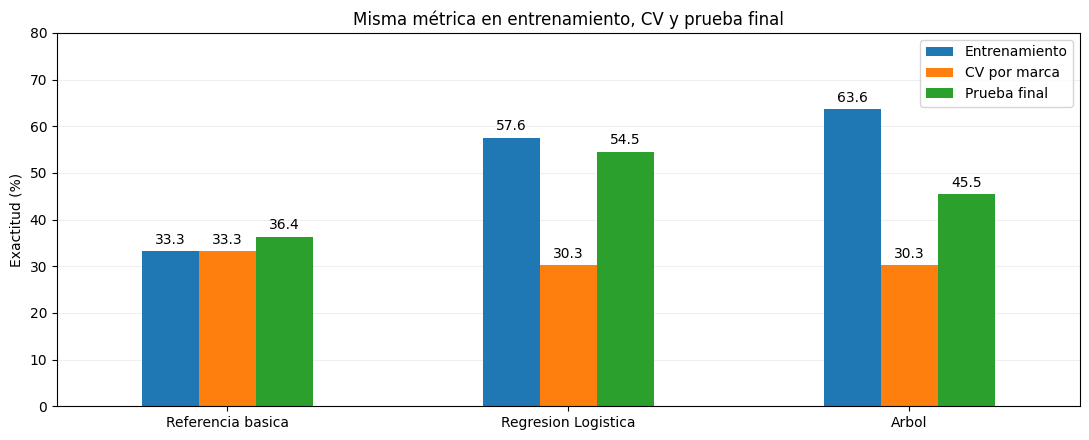

In [70]:
# Figura 2 del reporte final: se construye con la tabla calculada arriba.
datos_figura_2 = (
    tabla_final_reporte.set_index('Modelo')[
        ['Accuracy entrenamiento', 'Accuracy CV', 'Accuracy prueba']
    ]
    .mul(100)
    .rename(columns={
        'Accuracy entrenamiento': 'Entrenamiento',
        'Accuracy CV': 'CV por marca',
        'Accuracy prueba': 'Prueba final'
    })
)

ax = datos_figura_2.plot(kind='bar', figsize=(11, 4.5), rot=0)
ax.set_title('Misma métrica en entrenamiento, CV y prueba final')
ax.set_ylabel('Exactitud (%)')
ax.set_xlabel('')
ax.set_ylim(0, 80)
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt='%.1f', padding=3)
plt.tight_layout()
plt.show()

In [71]:
# Matrices de prueba y variables destacadas: lectura descriptiva, no causal.
for nombre in modelos:
    print(nombre, '— Matriz de prueba (filas reales, columnas predichas)')
    display(pd.DataFrame(
        matrices_prueba_final[nombre],
        index=['Real Bajo', 'Real Medio', 'Real Alto'],
        columns=['Pred Bajo', 'Pred Medio', 'Pred Alto']
    ))

importancia_arbol_final = pd.Series(
    modelos_entrenados_final['Arbol'].feature_importances_, index=variables_modelo
).sort_values(ascending=False)
coeficientes_logistica_final = pd.Series(
    np.abs(modelos_entrenados_final['Regresion Logistica'].named_steps['modelo'].coef_).mean(axis=0),
    index=variables_modelo
).sort_values(ascending=False)
print('Importancia de variables del árbol:')
display(importancia_arbol_final.round(3))
print('Magnitud media de coeficientes de Regresión Logística (variables escaladas):')
display(coeficientes_logistica_final.round(3))

Referencia basica — Matriz de prueba (filas reales, columnas predichas)


,Pred Bajo,Pred Medio,Pred Alto
Real Bajo,0,0,2
Real Medio,0,0,5
Real Alto,0,0,4


Regresion Logistica — Matriz de prueba (filas reales, columnas predichas)


,Pred Bajo,Pred Medio,Pred Alto
Real Bajo,1,1,0
Real Medio,0,2,3
Real Alto,0,1,3


Arbol — Matriz de prueba (filas reales, columnas predichas)


,Pred Bajo,Pred Medio,Pred Alto
Real Bajo,0,0,2
Real Medio,0,1,4
Real Alto,0,0,4


Importancia de variables del árbol:


monto_promedio       0.495
pct_garantia         0.391
anio                 0.114
pct_falta_info       0.000
motivos_distintos    0.000
dtype: float64

Magnitud media de coeficientes de Regresión Logística (variables escaladas):


anio                 0.406
pct_garantia         0.362
motivos_distintos    0.251
pct_falta_info       0.177
monto_promedio       0.167
dtype: float64

### comprobación

El conjunto de prueba tiene solo **11 observaciones** de seis marcas. Por eso no interpretamos unas pocas diferencias porcentuales como prueba de superioridad. La comparación de entrenamiento, validación y prueba permite detectar variación y posibles señales de sobreajuste; la validación cruzada interna es especialmente importante porque mantiene separadas las marcas.

Las ventas y la cantidad de quejas n* fueron entradas de los modelos: las usamos para calcular el nivel que queremos clasificar. Por eso las importancias de los modelos no demuestran causalmente la hipótesis sobre ventas. Esa relación se estudia descriptivamente con el indicador y la gráfica del tamaño de la marca. La prueba de esta parte y las tres evaluaciones anteriores tienen particiones distintas y no deben interpretarse como si fueran el mismo resultado.